# Imports and Models setup

In [1]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "8"
os.environ["OMP_NUM_THREADS"] = "8"

import argparse
import gc
import numpy as np, random
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, Gemma3ForCausalLM
from datasets import load_from_disk
from time import time
from tqdm import tqdm

import threading
from torch.utils.tensorboard import SummaryWriter
from torch.cuda.amp import autocast, GradScaler

seed = 0
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)


In [2]:
devices = [f'cuda:{i}' for i in [6,3,4,7]]
weight_type = (torch.bfloat16 if True or args.weight_type == "bf16" else torch.float32)

teacher   = Gemma3ForCausalLM.from_pretrained("google/gemma-3-4b-pt", trust_remote_code=True, cache_dir="/image-generation/imlloja", torch_dtype=weight_type, device_map = devices[0])  
tokenizer   = AutoTokenizer.from_pretrained("google/gemma-3-4b-pt", trust_remote_code=True, cache_dir="/image-generation/imlloja")

TOKENS_OF_INTEREST = torch.tensor(np.fromfile("gemma3_TOI", dtype=np.int32))
# ds = load_from_disk("/image-generation/imlloja/filtered-math")
# loader = torch.utils.data.DataLoader(ds, batch_size=4, shuffle=False)
torch.cuda.empty_cache()
gc.collect()        

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

123

In [3]:
torch.backends.cuda.matmul.allow_tf32 = True
torch.set_float32_matmul_precision("high")  # lets PyTorch use TF32 fast paths

# X: your real data here (float32). Move it to GPU once.
# X = torch.from_numpy(...).float()
X = teacher.lm_head.weight.data # demo placeholder
device = "cuda:6"
N, D, K = *X.shape, 100

# Use a big subset (or full data) for k-means++ init
init_subset = N # min(200_000, N)   # you can set N for full-data init if you like

In [4]:
ds = load_from_disk("/image-generation/imlloja/filtered-math")
loader = torch.utils.data.DataLoader(ds, batch_size=4, shuffle=False)

Loading dataset from disk:   0%|          | 0/48 [00:00<?, ?it/s]

In [5]:
for i, batch in tqdm(enumerate(loader)):
    # if i  < 10:
    #     continue
    lines = batch['text']
    batch = tokenizer(lines, max_length=1000, padding=True, truncation=True, return_tensors="pt")
    input_ids, attention_masks = batch['input_ids'].to(teacher.device), batch['attention_mask'].to(teacher.device)
    out_backbone = teacher.model.forward(input_ids=input_ids, attention_mask=attention_masks, return_dict=False, use_cache=False)[0]
    out_lm_head = teacher.lm_head(out_backbone).reshape(-1, N)
    
    # queries = out_backbone.reshape(-1, D)
    # _, gt_idx = torch.topk(out_lm_head, k=100, dim=-1)
    # p1 = dec.cluster_probs(Q, which=1, metric="dot", temperature=0.7)
    # p2 = dec.cluster_probs(Q, which=2, metric="dot", temperature=0.7)

    break
    
torch.cuda.empty_cache()
_, gt_idx = torch.topk(out_lm_head.reshape(-1, N), k=500, dim=-1)
Q = out_backbone.reshape(-1, D)

0it [00:00, ?it/s]


## Spherical K-Means

In [203]:
import torch
from typing import Tuple, Optional

# ------------------------------
# Utilities
# ------------------------------

def pick_device(device: Optional[str] = None) -> torch.device:
    if device is not None:
        return torch.device(device)
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

@torch.no_grad()
def _safe_l2_normalize(x: torch.Tensor, dim: int = -1, eps: float = 1e-8) -> torch.Tensor:
    # returns x / max(||x||, eps)
    n = x.norm(dim=dim, keepdim=True)
    n = torch.clamp(n, min=eps)
    return x / n

# ------------------------------
# k-means++ init (spherical)
# ------------------------------

@torch.no_grad()
def kmeanspp_init_subset_spherical(
    X: torch.Tensor,
    n_clusters: int,
    subset: int = 50000,
    device: Optional[str] = None,
    seed: int = 0,
) -> torch.Tensor:
    """
    Spherical k-means++ initialization on a random subset of X.
    X: (N, D) on CPU (recommended). Returns unit-norm centroids on chosen device (float32).
    """
    dev = pick_device(device)
    N = X.shape[0]
    subset = min(subset, N)
    g_cpu = torch.Generator(device="cpu").manual_seed(seed)
    idx = torch.randperm(N, generator=g_cpu)[:subset]
    # move subset and normalize to unit length
    Xs = _safe_l2_normalize(X[idx].to(dev, non_blocking=True).float(), dim=1)  # (S, D)

    # pick first center uniformly
    first = torch.randint(low=0, high=subset, size=(1,), device=dev)
    C = Xs[first].clone()  # (1, D), already unit-norm

    # distances to nearest center (on sphere: 1 - cosine = 0.5 * ||x - c||^2)
    # since Xs and C are unit-norm, we can use squared Euclidean as a proxy
    # d2 = ||x - c||^2 = 2(1 - cos)  -> proportional to spherical kmeans++
    d2 = ((Xs - C)**2).sum(dim=1)  # (S,)

    for _ in range(1, n_clusters):
        probs = (d2 / (d2.sum() + 1e-12)).clamp_min_(1e-12)
        next_i = torch.multinomial(probs, 1)        # (1,)
        C = torch.cat([C, Xs[next_i]], dim=0)       # (m+1, D)
        # update min distance to nearest chosen center
        new_d2 = ((Xs - C[-1])**2).sum(dim=1)       # (S,)
        d2 = torch.minimum(d2, new_d2)

    # ensure exact unit norm
    C = _safe_l2_normalize(C, dim=1)
    return C.float()

# ------------------------------
# Main spherical K-Means (chunked Lloyd)
# ------------------------------

@torch.no_grad()
def kmeans_chunked_spherical(
    X: torch.Tensor,
    n_clusters: int = 100,
    max_iters: int = 20,
    tol: float = 1e-4,
    chunk_size: int = 8192,
    init_subset: int = 50000,
    device: Optional[str] = None,
    verbose: bool = True,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Chunked spherical K-Means (cosine k-means).
    X           : (N, D) float tensor on CPU (recommended).
                  Magnitudes are ignored; we normalize internally.
    Returns     : (centroids[K, D] unit-norm on device, labels[N] on CPU)
    Objective   : maximize cosine similarity (equiv. minimize 1 - cosine).
    """
    dev = pick_device(device)
    N, D = X.shape

    # Initialize centroids on unit sphere
    C = kmeanspp_init_subset_spherical(X, n_clusters, subset=init_subset, device=dev)
    labels = torch.empty(N, dtype=torch.int64)  # keep on CPU

    prev_C = None
    for it in range(max_iters):
        # ----- Pass 1: Assign (by max cosine) -----
        # We'll compute xb_normed @ C.T per chunk; xb_normed is unit-norm
        inertia = 0.0  # sum of (1 - cos) ~ for monitoring
        for start in range(0, N, chunk_size):
            end = min(start + chunk_size, N)
            xb = X[start:end].to(dev, non_blocking=True).float()       # (B, D)
            xb = _safe_l2_normalize(xb, dim=1)                         # (B, D) unit
            sims = xb @ C.T                                            # (B, K) cosine
            vals, idxs = torch.max(sims, dim=1)                        # best cosine
            labels[start:end] = idxs.cpu()
            # inertia ~ sum(1 - cos); purely diagnostic
            inertia += float((1.0 - vals).sum().item())

        # ----- Pass 2: Update (mean on sphere + renorm) -----
        sums = torch.zeros_like(C)                    # (K, D) on dev
        counts = torch.zeros(n_clusters, device=dev, dtype=torch.long)

        for start in range(0, N, chunk_size):
            end = min(start + chunk_size, N)
            xb = X[start:end].to(dev, non_blocking=True).float()       # (B, D)
            xb = _safe_l2_normalize(xb, dim=1)                         # (B, D) unit
            labs = labels[start:end].to(dev, non_blocking=True)        # (B,)
            sums.index_add_(0, labs, xb)                               # sum of unit vectors
            counts += torch.bincount(labs, minlength=n_clusters)

        # handle empty clusters by reseeding from random (unit) points
        empty = (counts == 0).nonzero(as_tuple=False).flatten()
        if empty.numel() > 0:
            g = torch.Generator(device="cpu").manual_seed(1234 + it)
            rand_idx = torch.randperm(N, generator=g)[:empty.numel()]
            rep = _safe_l2_normalize(X[rand_idx].to(dev).float(), dim=1)
            sums[empty] = rep
            counts[empty] = 1

        newC = sums / counts.clamp_min(1).unsqueeze(1)
        newC = _safe_l2_normalize(newC, dim=1)  # project back to the unit sphere

        # convergence: mean angular shift (use cosine distance)
        # mean( ||C - newC|| ) is fine, but cosine-based shift is more interpretable:
        with torch.no_grad():
            cos_shift = torch.clamp((C * newC).sum(dim=1), -1.0, 1.0)
            # convert to an average angular change (radians)
            mean_angle = torch.acos(cos_shift).mean().item()

        C = newC
        if verbose:
            print(f"[iter {it+1}/{max_iters}] inertia~={inertia:.4e}  mean_angle={mean_angle:.6f} rad")

        if mean_angle < tol:
            break

    return C, labels


In [207]:
torch.cuda.empty_cache()
gc.collect()

85591

In [218]:
C_cos, L_cos = kmeans_chunked_spherical(
    X, n_clusters=300, max_iters=20, tol=1e-4,
    chunk_size=10000, init_subset=10000, device=None, verbose=True
)

[iter 1/20] inertia~=2.1872e+05  mean_angle=0.983743 rad
[iter 2/20] inertia~=1.8597e+05  mean_angle=0.308217 rad
[iter 3/20] inertia~=1.8098e+05  mean_angle=0.188619 rad
[iter 4/20] inertia~=1.7904e+05  mean_angle=0.132636 rad
[iter 5/20] inertia~=1.7799e+05  mean_angle=0.101814 rad
[iter 6/20] inertia~=1.7735e+05  mean_angle=0.076365 rad
[iter 7/20] inertia~=1.7697e+05  mean_angle=0.064135 rad
[iter 8/20] inertia~=1.7667e+05  mean_angle=0.053502 rad
[iter 9/20] inertia~=1.7645e+05  mean_angle=0.046206 rad
[iter 10/20] inertia~=1.7628e+05  mean_angle=0.039531 rad
[iter 11/20] inertia~=1.7616e+05  mean_angle=0.034609 rad
[iter 12/20] inertia~=1.7605e+05  mean_angle=0.031341 rad
[iter 13/20] inertia~=1.7595e+05  mean_angle=0.027217 rad
[iter 14/20] inertia~=1.7588e+05  mean_angle=0.023894 rad
[iter 15/20] inertia~=1.7583e+05  mean_angle=0.020835 rad
[iter 16/20] inertia~=1.7579e+05  mean_angle=0.019684 rad
[iter 17/20] inertia~=1.7576e+05  mean_angle=0.018088 rad
[iter 18/20] inertia~=1

In [219]:
vals, token_ids = torch.sort(L_cos, dim=-1)

In [228]:
tokenizer.batch_decode(token_ids[vals==15].unsqueeze(1))

[' Bh',
 ' Raj',
 ' Chen',
 ' Singh',
 ' Khan',
 ' Hindi',
 ' Yang',
 ' Wang',
 ' Dh',
 ' Ji',
 ' Abd',
 ' Liu',
 ' Zhang',
 ' Kumar',
 ' Xia',
 ' lakh',
 ' bhav',
 ' Shah',
 ' Shang',
 ' Pradesh',
 ' Abu',
 ' Chand',
 ' Hindu',
 ' Muhammad',
 ' Wu',
 ' Jin',
 ' Tamil',
 ' Ahmed',
 ' Punj',
 ' crore',
 ' Xu',
 ' Bhar',
 ' Emir',
 ' BJP',
 ' Hua',
 ' Modi',
 'abhav',
 ' Sharma',
 ' Xi',
 ' Gandhi',
 ' Tian',
 ' Huang',
 ' Bhag',
 ' Jiang',
 ' Mohammed',
 ' Dong',
 ' Rajas',
 ' Hari',
 ' Abdul',
 ' Ahmad',
 ' Feng',
 ' Gujar',
 ' Utt',
 ' Fuj',
 ' Shi',
 ' Zhao',
 ' dham',
 ' Cheng',
 ' Raman',
 ' Zhou',
 ' Wei',
 ' Vij',
 ' Qing',
 ' Xiao',
 ' Sultan',
 ' Yuan',
 ' lakhs',
 ' Buddh',
 ' Bollywood',
 ' Kapoor',
 ' Khal',
 ' Minh',
 ' Zhu',
 ' Guang',
 ' Shri',
 ' Gupta',
 ' Krishna',
 ' crores',
 ' Marathi',
 ' Wong',
 ' Himal',
 ' Patel',
 ' Swami',
 ' Vivekan',
 ' yuan',
 ' Palash',
 ' Shiv',
 ' Vivekananda',
 ' Ibrahim',
 ' Rao',
 ' Shan',
 ' Dhar',
 ' Yosh',
 ' Mahar',
 ' Hiro',
 ' R

# K-Means Setup and initialization

In [6]:
import shutil
from pprint import PrettyPrinter

def pretty_list(lst):
    cols = shutil.get_terminal_size().columns  # detect screen width
    pp = PrettyPrinter(width=cols, compact=True)
    pp.pprint(lst)

In [7]:
## K-Means setup

import math
import torch
import matplotlib.pyplot as plt
from typing import Tuple, Optional

def pick_device(device: Optional[str] = None) -> torch.device:
    if device is not None:
        return torch.device(device)
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

@torch.no_grad()
def _pairwise_sq_dists(x: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
    """
    Return squared distances between rows of x (B x D) and rows of c (K x D).
    Uses ||x||^2 + ||c||^2 - 2 x c^T for speed and memory efficiency.
    """
    x_norm = (x**2).sum(dim=1, keepdim=True)          # (B, 1)
    c_norm = (c**2).sum(dim=1).unsqueeze(0)           # (1, K)
    d2 = x_norm + c_norm - 2.0 * (x @ c.T)            # (B, K)
    return d2.clamp_min_(0)  # numerical safety

# ------------------------------
# k-means++ init on a subset
# ------------------------------

@torch.no_grad()
def kmeanspp_init_subset(
    X: torch.Tensor,
    n_clusters: int,
    subset: int = 50000,
    device: Optional[str] = None,
    seed: int = 0,
) -> torch.Tensor:
    """
    k-means++ initialization on a random subset of X.
    X: (N, D) on CPU (recommended). Returns centroids on chosen device (float32).
    """
    dev = pick_device(device)
    N = X.shape[0]
    subset = min(subset, N)
    g_cpu = torch.Generator(device="cpu").manual_seed(seed)
    idx = torch.randperm(N, generator=g_cpu)[:subset]
    Xs = X[idx].to(dev, non_blocking=True).float()   # (S, D)

    # pick first center uniformly
    first = torch.randint(low=0, high=subset, size=(1,), device=dev)
    C = Xs[first].clone()                            # (1, D)

    # distances to nearest center
    d2 = _pairwise_sq_dists(Xs, C).squeeze(1)       # (S,)

    for _ in range(1, n_clusters):
        probs = (d2 / (d2.sum() + 1e-12)).clamp_min_(1e-12)
        next_i = torch.multinomial(probs, 1)        # (1,)
        C = torch.cat([C, Xs[next_i]], dim=0)       # (m+1, D)
        # update distances to nearest chosen center
        new_d2 = _pairwise_sq_dists(Xs, C[-1:].contiguous()).squeeze(1)
        d2 = torch.minimum(d2, new_d2)

    return C.float()

# ------------------------------
# Main K-Means (chunked Lloyd)
# ------------------------------

@torch.no_grad()
def kmeans_chunked(
    X: torch.Tensor,
    n_clusters: int = 100,
    max_iters: int = 10,
    tol: float = 1e-4,
    chunk_size: int = 8192,
    init_subset: int = 50000,
    device: Optional[str] = None,
    verbose: bool = True,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Chunked K-Means for very large X.
    X           : (N, D) float32 tensor on CPU (recommended).
    Returns     : (centroids[K, D] on device, labels[N] on CPU)
    """
    dev = pick_device(device)
    N, D = X.shape

    # Initialize centroids
    C = kmeanspp_init_subset(X, n_clusters, subset=init_subset, device=dev)
    labels = torch.empty(N, dtype=torch.int64)  # keep on CPU

    for it in range(max_iters):
        # ----- Pass 1: Assign -----
        inertia = 0.0
        for start in range(0, N, chunk_size):
            end = min(start + chunk_size, N)
            xb = X[start:end].to(dev, non_blocking=True).float()  # (B, D)

            d2 = _pairwise_sq_dists(xb, C)                        # (B, K)
            vals, idxs = torch.min(d2, dim=1)
            labels[start:end] = idxs.cpu()
            inertia += float(vals.sum().item())

        # ----- Pass 2: Update -----
        sums = torch.zeros_like(C)                # (K, D) on dev
        counts = torch.zeros(n_clusters, device=dev, dtype=torch.long)

        for start in range(0, N, chunk_size):
            end = min(start + chunk_size, N)
            xb = X[start:end].to(dev, non_blocking=True).float()  # (B, D)
            labs = labels[start:end].to(dev, non_blocking=True)   # (B,)

            # accumulate sums and counts per cluster
            sums.index_add_(0, labs, xb)
            counts += torch.bincount(labs, minlength=n_clusters)

        # handle empty clusters by reseeding from random points
        empty = (counts == 0).nonzero(as_tuple=False).flatten()
        if empty.numel() > 0:
            g = torch.Generator(device="cpu").manual_seed(1234 + it)
            rand_idx = torch.randperm(N, generator=g)[:empty.numel()]
            rep = X[rand_idx].to(dev, non_blocking=True).float()
            sums[empty] = rep
            counts[empty] = 1

        newC = sums / counts.clamp_min(1).unsqueeze(1)

        # convergence check: mean centroid shift
        shift = torch.norm(C - newC, dim=1).mean().item()
        C = newC
        if verbose:
            print(f"[iter {it+1}/{max_iters}] inertia={inertia:.4e}  mean_shift={shift:.6f}")
        if shift < tol:
            break

    return C, labels

# ------------------------------
# Visualization (PCA -> 2D)
# ------------------------------

@torch.no_grad()
def pca_visualize(
    X: torch.Tensor,
    labels: torch.Tensor,
    centroids: torch.Tensor,
    max_points_per_cluster: int = 500,
    device: Optional[str] = None,
):
    """
    Projects a balanced subset + centroids to 2D via PCA and plots.
    X must be on CPU; labels on CPU; centroids on (cpu or cuda).
    """
    dev = pick_device(device)
    K = centroids.shape[0]
    N = X.shape[0]
    torch.manual_seed(0)
    torch.use_deterministic_algorithms(True)
    # build a balanced sample across clusters
    picks = []
    g = torch.Generator(device="cpu").manual_seed(0)
    for k in range(K):
        idx = (labels == k).nonzero(as_tuple=False).flatten()
        if idx.numel() == 0:
            continue
        m = min(max_points_per_cluster, idx.numel())
        perm = torch.randperm(idx.numel(), generator=g)[:m]
        picks.append(idx[perm])

    if len(picks) == 0:
        print("No points to visualize.")
        return

    sel_idx = torch.cat(picks, dim=0)
    Xs = X[sel_idx].float()           # (M, D), CPU
    ls = labels[sel_idx]              # (M,)

    # PCA with torch (fast low-rank SVD)
    Xs_mean = Xs.mean(dim=0, keepdim=True)
    Xc = Xs - Xs_mean
    U, S, V = torch.pca_lowrank(Xc, q=4, center=False)   # V: (D,2)
    X2 = (Xc @ V[:, :2])                                 # (M, 2)
    C2 = ((centroids.to(Xs.device) - Xs_mean) @ V[:, :2])# (K, 2)
    X3 = (Xc @ V[:, 2:4])                                 # (M, 2)
    C3 = ((centroids.to(Xs.device) - Xs_mean) @ V[:, 2:4])# (K, 2)

    # Plot
    fig, ax = plt.subplots(figsize=(15,15))
    sc = ax.scatter(X2[:, 0].cpu(), X2[:, 1].cpu(), c=ls.cpu(), s=3, alpha=0.6)
    ax.scatter(C2[:, 0].cpu(), C2[:, 1].cpu(), marker='x', s=120, linewidths=2)
    ax.set_title("K-Means clusters (PCA to 2D)")
    ax.set_xlabel(f"PC1 eigenvalue {S[0] :.4f}")
    ax.set_ylabel(f"PC2 eigenvalue {S[1] :.4f}")
    plt.tight_layout()
    plt.show()
    # Plot
    fig, ax = plt.subplots(figsize=(15,15))
    sc = ax.scatter(X3[:, 0].cpu(), X3[:, 1].cpu(), c=ls.cpu(), s=3, alpha=0.6)
    ax.scatter(C3[:, 0].cpu(), C3[:, 1].cpu(), marker='x', s=120, linewidths=2)
    ax.set_title("K-Means clusters (PCA to 2D)")
    ax.set_xlabel(f"PC3 eigenvalue {S[2] :.4f}")
    ax.set_ylabel(f"PC4 eigenvalue {S[3] :.4f}")
    plt.tight_layout()
    plt.show()

# ------------------------------
# Inspect nearest points per cluster
# ------------------------------

@torch.no_grad()
def nearest_examples_per_cluster(
    X: torch.Tensor,
    labels: torch.Tensor,
    centroids: torch.Tensor,
    topn: int = 5,
    chunk_size: int = 8192,
    device: Optional[str] = None,
) -> dict:
    """
    Returns {cluster_id: [(idx, dist2), ... topn]} of nearest examples.
    """
    dev = pick_device(device)
    K = centroids.shape[0]
    out = {}

    for k in range(K):
        idx = (labels == k).nonzero(as_tuple=False).flatten()
        if idx.numel() == 0:
            out[k] = []
            continue

        best_vals = torch.full((topn,), float("inf"))
        best_idx  = torch.full((topn,), -1, dtype=torch.long)

        c = centroids[k:k+1].to(dev)
        for start in range(0, idx.numel(), chunk_size):
            ids = idx[start:start + chunk_size]
            xb = X[ids].to(dev, non_blocking=True).float()
            d2 = ((xb - c)**2).sum(dim=1)  # (B,)

            # keep the topn smallest distances
            all_vals = torch.cat([best_vals, d2.cpu()], dim=0)
            all_ids  = torch.cat([best_idx,  ids.cpu()], dim=0)
            # argsort (smallest first) and keep topn
            perm = torch.argsort(all_vals)[:topn]
            best_vals = all_vals[perm]
            best_idx  = all_ids[perm]

        out[k] = list(zip(best_idx.tolist(), best_vals.tolist()))
    return out


In [8]:
@torch.no_grad()
def tsne_visualize(
    X: torch.Tensor,
    labels: torch.Tensor,
    centroids: torch.Tensor,
    max_points_per_cluster: int = 500,
    perplexity: float = 30.0,
    learning_rate: str | float = "auto",  # sklearn >=1.2 supports "auto"
    n_iter: int = 1000,
    metric: str = "euclidean",
    random_state: int = 0,
):
    """
    t-SNE visualization of a balanced subset + centroids.
    - X, labels expected on CPU; centroids can be CPU/CUDA.
    - Centroids are embedded jointly with the sampled points (by concatenating),
      so they appear as 'points' placed relative to data.
    """
    try:
        from sklearn.manifold import TSNE
    except Exception as e:
        raise ImportError(
            "scikit-learn is required for TSNE. Install with `pip install scikit-learn`."
        ) from e

    K = centroids.shape[0]
    N = X.shape[0]

    # --- Balanced sample across clusters (deterministic) ---
    picks = []
    g = torch.Generator(device="cpu").manual_seed(0)
    for k in range(K):
        idx = (labels == k).nonzero(as_tuple=False).flatten()
        if idx.numel() == 0:
            continue
        m = min(max_points_per_cluster, idx.numel())
        perm = torch.randperm(idx.numel(), generator=g)[:m]
        picks.append(idx[perm])

    if not picks:
        print("No points to visualize.")
        return

    sel_idx = torch.cat(picks, dim=0)
    Xs = X[sel_idx].float().cpu()              # (M, D)
    ls = labels[sel_idx].cpu()                 # (M,)
    C  = centroids.to(Xs.device).float()       # (K, D)

    # --- Concatenate sampled points + centroids so TSNE embeds both together ---
    X_joint = torch.cat([Xs, C], dim=0).numpy()  # to numpy for sklearn
    M = Xs.shape[0]

    # --- t-SNE (Barnes-Hut for n_components=2) ---
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate=learning_rate,
        n_iter=n_iter,
        metric=metric,
        init="pca",            # stabilizes results
        random_state=random_state,
        verbose=1,
        n_jobs=None,           # sklearn 1.4+ uses threadpoolctl; leave default
        # angle=0.5,           # (optional) tradeoff speed/accuracy for Barnes-Hut
    )
    Y = tsne.fit_transform(X_joint)            # (M+K, 2)
    Y_points = Y[:M]
    Y_centers = Y[M:]

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(9, 7))
    sc = ax.scatter(Y_points[:, 0], Y_points[:, 1], c=ls.numpy(), s=3, alpha=0.6)
    ax.scatter(Y_centers[:, 0], Y_centers[:, 1], marker='x', s=120, linewidths=2, c="black")
    ax.set_title(f"t-SNE (perplexity={perplexity}, iter={n_iter})")
    ax.set_xlabel("tSNE-1")
    ax.set_ylabel("tSNE-2")
    plt.tight_layout()
    plt.show()


In [9]:
K1, K2 = 50, 1000

# You have X (N,D). Build two partitions (your existing k-means code):
device = devices[2]
C1, L1 = kmeans_chunked(
    X=X,                        # (GPU tensor now)
    n_clusters=K1,
    max_iters=50,
    tol=1e-4,
    chunk_size=N,               # process all points per pass on H100
    init_subset=init_subset,
    device=device,
    verbose=True,
)
C2, L2 = kmeans_chunked(
    X=X,                        # (GPU tensor now)
    n_clusters=K2,
    max_iters=50,
    tol=1e-4,
    chunk_size=N,               # process all points per pass on H100
    init_subset=init_subset,
    device=device,
    verbose=True,
)


[iter 1/50] inertia=4.3754e+05  mean_shift=0.890321
[iter 2/50] inertia=2.3215e+05  mean_shift=0.082011
[iter 3/50] inertia=2.2812e+05  mean_shift=0.046106
[iter 4/50] inertia=2.2722e+05  mean_shift=0.033055
[iter 5/50] inertia=2.2672e+05  mean_shift=0.024484
[iter 6/50] inertia=2.2641e+05  mean_shift=0.021093
[iter 7/50] inertia=2.2619e+05  mean_shift=0.015128
[iter 8/50] inertia=2.2608e+05  mean_shift=0.010880
[iter 9/50] inertia=2.2601e+05  mean_shift=0.010206
[iter 10/50] inertia=2.2593e+05  mean_shift=0.009911
[iter 11/50] inertia=2.2586e+05  mean_shift=0.009231
[iter 12/50] inertia=2.2579e+05  mean_shift=0.007576
[iter 13/50] inertia=2.2575e+05  mean_shift=0.006117
[iter 14/50] inertia=2.2572e+05  mean_shift=0.005359
[iter 15/50] inertia=2.2570e+05  mean_shift=0.004846
[iter 16/50] inertia=2.2568e+05  mean_shift=0.004597
[iter 17/50] inertia=2.2567e+05  mean_shift=0.004102
[iter 18/50] inertia=2.2565e+05  mean_shift=0.003760
[iter 19/50] inertia=2.2564e+05  mean_shift=0.003681
[i

### Clustering Visualization

In [25]:
import torch
import matplotlib.pyplot as plt
from ipywidgets import VBox, HBox, Checkbox, interactive_output
from typing import Optional

@torch.no_grad()
def pca_visualize_interactive(
    X: torch.Tensor,
    labels: torch.Tensor,
    centroids: torch.Tensor,
    max_points_per_cluster: int = 500,
    device: Optional[str] = None,
    initial=True,
):
    """
    Projects a balanced subset + centroids to 2D via PCA and shows an
    interactive widget where you can hide/show each cluster.
    """
    K = centroids.shape[0]
    N = X.shape[0]
    torch.manual_seed(0)
    # torch.use_deterministic_algorithms(True)
    # reproducible sampling
    g = torch.Generator(device="cpu").manual_seed(0)
    picks = []
    for k in range(K):
        idx = (labels == k).nonzero(as_tuple=False).flatten()
        if idx.numel() == 0:
            continue
        m = min(max_points_per_cluster, idx.numel())
        perm = torch.randperm(idx.numel(), generator=g)[:m]
        picks.append(idx[perm])

    if not picks:
        print("No points to visualize.")
        return

    sel_idx = torch.cat(picks, dim=0)
    Xs = X[sel_idx].float()           # (M, D), CPU
    ls = labels[sel_idx]              # (M,)

    # PCA with torch
    Xs_mean = Xs.mean(dim=0, keepdim=True)
    Xc = Xs - Xs_mean
    U, S, V = torch.pca_lowrank(Xc, q=4, center=False)
    X2 = (Xc @ V[:, :2])
    C2 = ((centroids.to(Xs.device) - Xs_mean) @ V[:, :2])

    # --- Plot setup ---
    fig, ax = plt.subplots(figsize=(15, 15))
    scatters = {}
    for k in range(K):
        mask = (ls == k)
        pts = ax.scatter(
            X2[mask, 0].cpu().detach().numpy(), X2[mask, 1].cpu().detach().numpy(),
            s=6, alpha=0.6, label=f"Cluster {k}"
        )
        cen = ax.scatter(
            C2[k, 0].cpu().detach().numpy(), C2[k, 1].cpu().detach().numpy(),
            marker='x', s=120, linewidths=2, c="black"
        )
        scatters[k] = (pts, cen)

    ax.set_title("K-Means clusters (PCA to 2D)")
    ax.set_xlabel(f"PC1 eigenvalue {S[0]:.4f}")
    ax.set_ylabel(f"PC2 eigenvalue {S[1]:.4f}")
    # ax.legend()
    plt.close(fig)


    # --- Widgets ---
    checkboxes = {k: Checkbox(value=initial, description=f"Cluster {k}") for k in range(K)}

    def update(**kwargs):
        for k, visible in kwargs.items():
            pts, cen = scatters[int(k)]
            pts.set_visible(visible)
            cen.set_visible(visible)
        fig.canvas.draw_idle()
        display(fig)


    ui = VBox([HBox(list(checkboxes.values())[i:i+5]) 
               for i in range(0, K, 5)])  # group in rows of 5 checkboxes
    out = interactive_output(update, {str(k): cb for k, cb in checkboxes.items()})
    display(ui, out)


In [26]:
pca_visualize_interactive(X, L2, C2, max_points_per_cluster=500, initial=False)


Output()

In [35]:
Q.shape

torch.Size([4000, 2560])

In [41]:
(Q/Q.norm(dim=0)).abs().mean()

tensor(0.0124, device='cuda:6', dtype=torch.bfloat16, grad_fn=<MeanBackward0>)

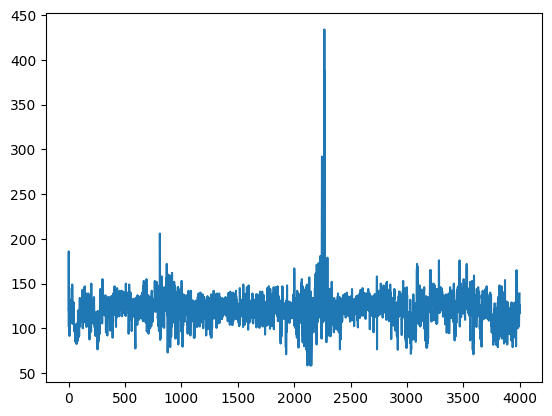

In [34]:
plt.plot(Q.norm(dim=1).float().detach().cpu().numpy())

Accordion(children=(VBox(children=(HBox(children=(Dropdown(description='X axis', options=(('PC 1', 0), ('PC 2'…

Output()

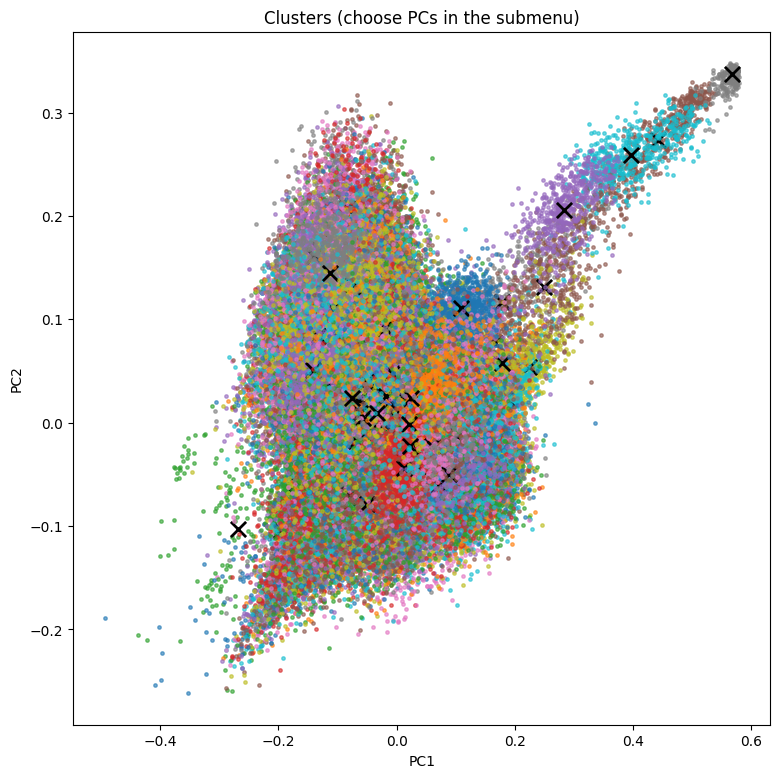

In [30]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import VBox, HBox, Checkbox, Dropdown, Accordion, interactive_output
from IPython.display import display
from typing import Optional

@torch.no_grad()
def pca_visualize_pcs_interactive(
    X: torch.Tensor,
    labels: torch.Tensor,
    centroids: torch.Tensor,
    max_points_per_cluster: int = 500,
    device: Optional[str] = None,
):
    """
    Interactive PCA visualization with:
      - full PCA (via SVD) on a balanced subsample
      - per-cluster show/hide (points + centroid)
      - dropdowns to choose which principal components to plot (PC_i vs PC_j)
      - controls collapsed in an Accordion to save space

    Notes:
      • X, labels on CPU; centroids can be on CPU or CUDA (moved as needed).
      • Uses U*S for sample projections; projects centroids on-the-fly via V.
    """
    # ---------- Balanced sample ----------
    K = int(centroids.shape[0])
    g = torch.Generator(device="cpu").manual_seed(0)

    picks = []
    for k in range(K):
        idx = (labels == k).nonzero(as_tuple=False).flatten()
        if idx.numel() == 0:
            continue
        m = min(max_points_per_cluster, idx.numel())
        perm = torch.randperm(idx.numel(), generator=g)[:m]
        picks.append(idx[perm])

    if not picks:
        print("No points to visualize.")
        return

    sel_idx = torch.cat(picks, dim=0)
    Xs = X[sel_idx].float().cpu()       # (M, D)
    ls = labels[sel_idx].cpu()          # (M,)
    K_eff = int(ls.max().item() + 1) if ls.numel() else K

    # ---------- Full PCA via SVD ----------
    # Xc = U S V^T  (U: M×r, S: r, V: D×r), r=min(M, D)
    Xs_mean = Xs.mean(dim=0, keepdim=True)
    Xc = Xs - Xs_mean

    # full_matrices=False gives r=min(M,D) components
    U, S, Vh = torch.linalg.svd(Xc, full_matrices=False)
    V = Vh.transpose(0, 1)   # D × r
    r = V.shape[1]           # number of PCs available

    # Sample projections for ALL PCs are U * S (broadcast)
    # X_proj[:, j] = U[:, j] * S[j]
    X_proj = U * S  # shape (M, r)

    # Function to compute centroids projected on selected PCs
    C = (centroids.to(Xs.device) - Xs_mean)            # (K, D)
    def centroid_pc_coords(pc_idx):
        # pc_idx is an int in [0, r-1]
        # C_proj[:, pc] = C @ V[:, pc]
        return (C @ V[:, pc_idx]).cpu().numpy()

    # ---------- Matplotlib figure ----------
    # Default PCs to show initially
    default_pcx = 0  # PC1
    default_pcy = 1  # PC2

    fig, ax = plt.subplots(figsize=(9, 9))
    scatters_pts = {}
    scatters_cen = {}

    # Precompute numpy arrays for initial PCs
    Xx = X_proj[:, default_pcx].cpu().numpy()
    Xy = X_proj[:, default_pcy].cpu().numpy()
    Cx = centroid_pc_coords(default_pcx)
    Cy = centroid_pc_coords(default_pcy)

    # Per-cluster scatters (points + centroid “x”)
    for k in range(K):
        mask = (ls == k).numpy()
        pts = ax.scatter(
            Xx[mask], Xy[mask],
            s=6, alpha=0.6, label=f"Cluster {k}"
        )
        cen = ax.scatter(
            Cx[k], Cy[k],
            marker='x', c='black', s=120, linewidths=2
        )
        scatters_pts[k] = pts
        scatters_cen[k] = cen

    ax.set_title("Clusters (choose PCs in the submenu)")
    ax.set_xlabel(f"PC{default_pcx+1}")
    ax.set_ylabel(f"PC{default_pcy+1}")
    # ax.legend(loc="best", fontsize=9)
    plt.close(fig)  # we'll display via widgets

    # ---------- Widgets (Accordion “Controls”) ----------
    # Cluster visibility checkboxes
    checks = {k: Checkbox(value=False, description=f"{k}") for k in range(K)}

    # Dropdowns for PC axes
    # Human-friendly labels "PC 1", "PC 2", ... mapped to indices 0..r-1
    options = [(f"PC {i+1}", i) for i in range(r)]
    dd_x = Dropdown(description="X axis", options=options, value=default_pcx)
    dd_y = Dropdown(description="Y axis", options=options, value=default_pcy)

    # Layout controls in an Accordion (to save space)
    clusters_row_groups = [HBox(list(checks.values())[i:i+8]) for i in range(0, K, 8)]
    clusters_box = VBox(clusters_row_groups) if clusters_row_groups else VBox()
    axes_box = HBox([dd_x, dd_y])

    acc = Accordion(children=[VBox([axes_box]), clusters_box])
    acc.set_title(0, "Axes (PCs)")
    acc.set_title(1, "Clusters")
    acc.selected_index = None  # collapsed by default

    # ---------- Update function ----------
    def update(**kwargs):
        # kwargs has entries like {"pcx": int, "pcy": int, "0": bool, "1": bool, ...}
        pcx = kwargs.get("pcx", default_pcx)
        pcy = kwargs.get("pcy", default_pcy)

        # Update point positions for selected PCs (use precomputed X_proj)
        newX = np.c_[X_proj[:, pcx].cpu().numpy(), X_proj[:, pcy].cpu().numpy()]
        # Update centroid positions for selected PCs (compute on-the-fly)
        newCx = centroid_pc_coords(pcx)
        newCy = centroid_pc_coords(pcy)

        # Apply to each cluster: offsets + visibility
        for k in range(K):
            mask = (ls == k).numpy()
            # Update point offsets
            scatters_pts[k].set_offsets(newX[mask])
            # Update centroid offsets (single point)
            scatters_cen[k].set_offsets(np.array([[newCx[k], newCy[k]]]))

            # Visibility from checkbox
            visible = kwargs.get(str(k), True)
            scatters_pts[k].set_visible(visible)
            scatters_cen[k].set_visible(visible)

        # Axis labels
        ax.set_xlabel(f"PC{pcx+1}")
        ax.set_ylabel(f"PC{pcy+1}")
        fig.canvas.draw_idle()
        display(fig)

    # Wire widgets → update
    controls = {"pcx": dd_x, "pcy": dd_y}
    controls.update({str(k): cb for k, cb in checks.items()})
    out = interactive_output(update, controls)

    # Display UI + plot output
    display(acc, out)

    # Trigger an initial render
    update(pcx=default_pcx, pcy=default_pcy, **{str(k): True for k in range(K)})

pca_visualize_pcs_interactive(
    X.cpu().detach(), L2.cpu().detach(), C2.cpu().detach(), max_points_per_cluster=500
)

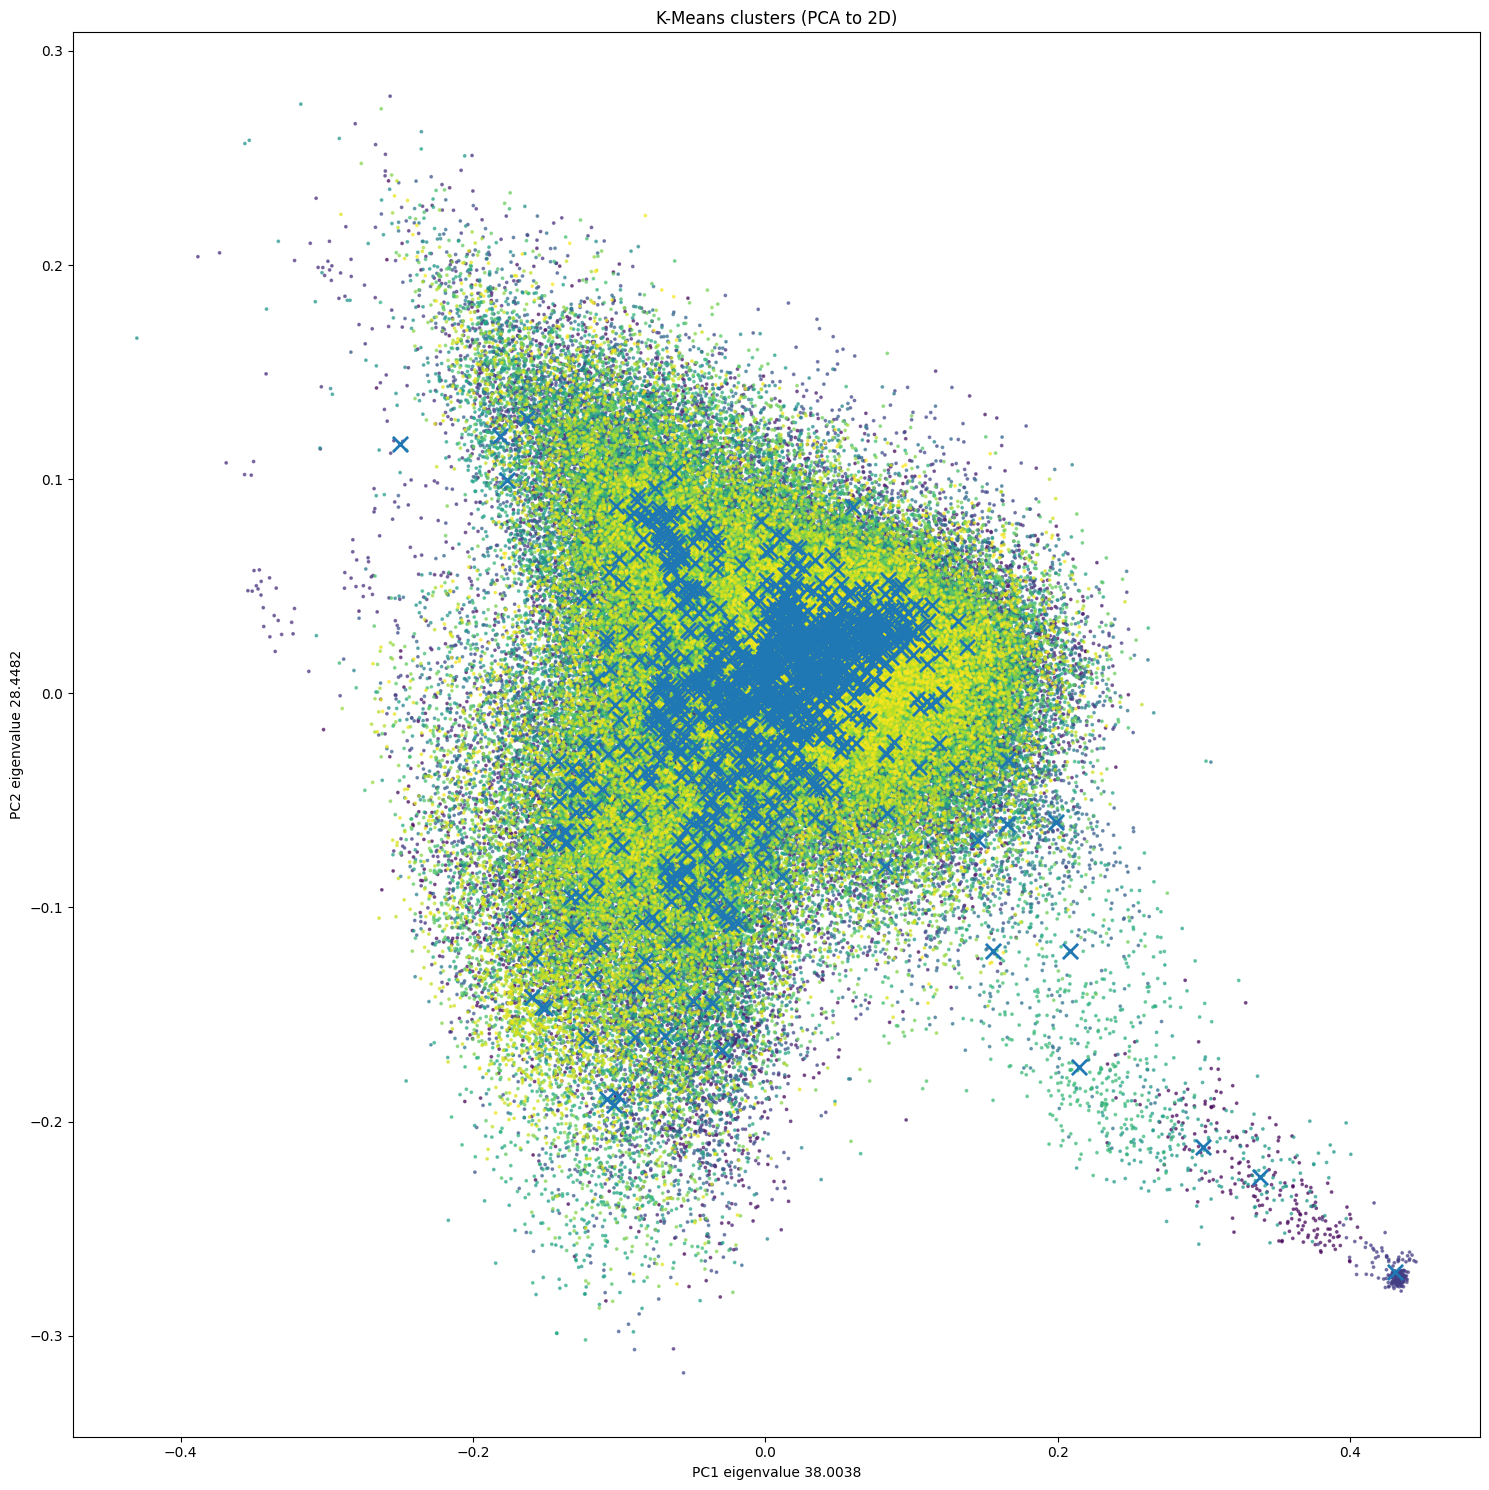

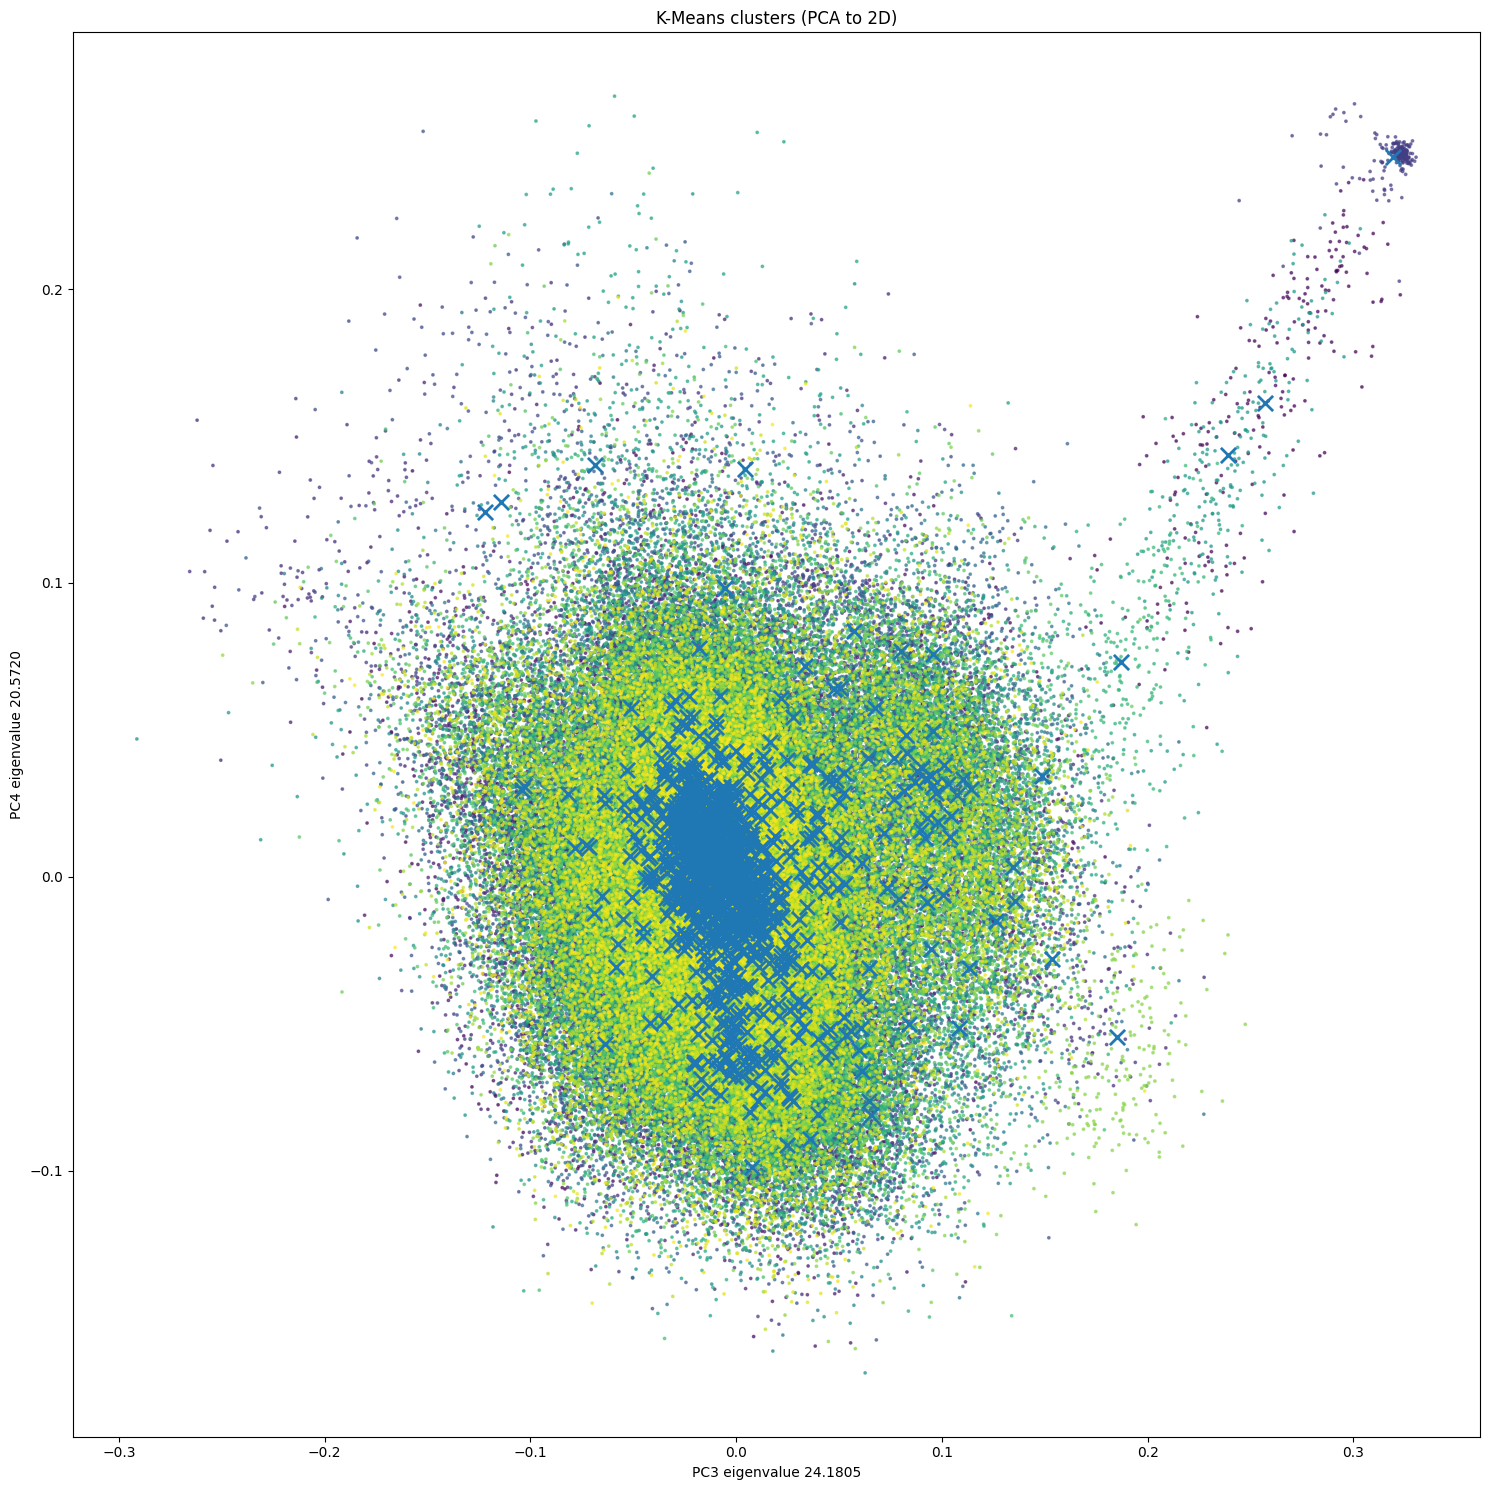

In [32]:
# For PCA visualization, move just the needed sample back to CPU
pca_visualize(
    X=X.detach().cpu(),         # only needed for the selected subset
    labels=L2.cpu(),
    centroids=C2,        # can stay on GPU
    max_points_per_cluster=200,
    device=device,
)


In [8]:
len(labels)

262208

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10100 samples in 0.007s...
[t-SNE] Computed neighbors for 10100 samples in 1.496s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10100
[t-SNE] Computed conditional probabilities for sample 2000 / 10100
[t-SNE] Computed conditional probabilities for sample 3000 / 10100
[t-SNE] Computed conditional probabilities for sample 4000 / 10100
[t-SNE] Computed conditional probabilities for sample 5000 / 10100
[t-SNE] Computed conditional probabilities for sample 6000 / 10100
[t-SNE] Computed conditional probabilities for sample 7000 / 10100
[t-SNE] Computed conditional probabilities for sample 8000 / 10100
[t-SNE] Computed conditional probabilities for sample 9000 / 10100
[t-SNE] Computed conditional probabilities for sample 10000 / 10100
[t-SNE] Computed conditional probabilities for sample 10100 / 10100
[t-SNE] Mean sigma: 0.054620
[t-SNE] KL divergence after 250 iterations with early exaggeration: 109.761185
[t-SNE] KL

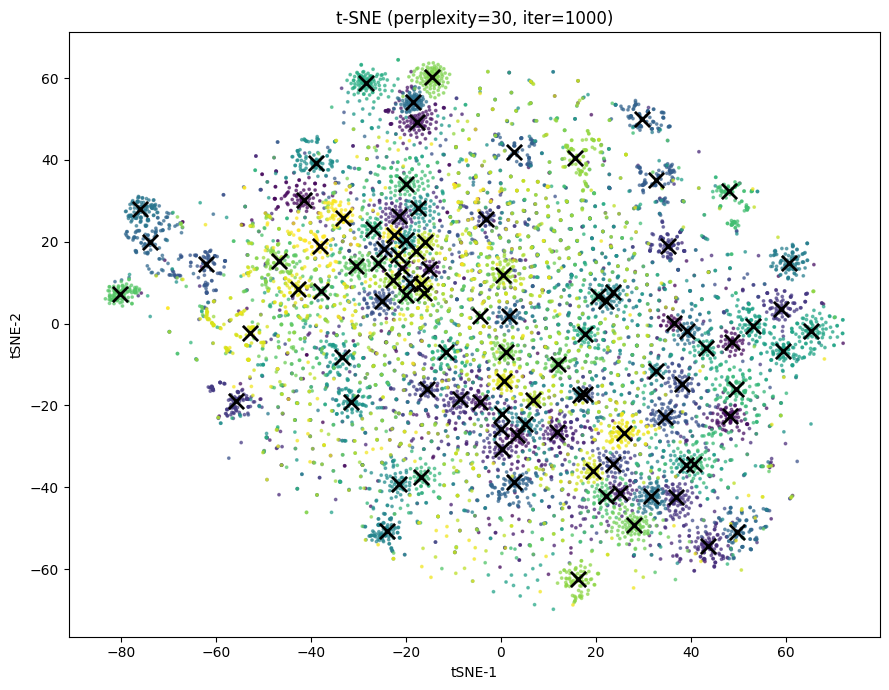

In [9]:
tsne_visualize(X, labels, centroids, max_points_per_cluster=100, perplexity=30, n_iter=1000, metric='cosine')


In [10]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

@torch.no_grad()
def _balanced_sample_indices(labels: torch.Tensor, K: int, max_points_per_cluster=500, seed=0):
    picks = []
    g = torch.Generator(device="cpu").manual_seed(seed)
    for k in range(K):
        idx = (labels == k).nonzero(as_tuple=False).flatten()
        if idx.numel() == 0:
            continue
        m = min(max_points_per_cluster, idx.numel())
        perm = torch.randperm(idx.numel(), generator=g)[:m]
        picks.append(idx[perm])
    if not picks:
        raise ValueError("No points to visualize (no labels found).")
    return torch.cat(picks, dim=0)

@torch.no_grad()
def tsne_compare_perplexities(
    X: torch.Tensor,
    labels: torch.Tensor,
    centroids: torch.Tensor,
    perplexities=(5, 10, 30, 50),
    max_points_per_cluster: int = 400,
    metric: str = "euclidean",         # try "cosine" for embeddings
    n_iter: int = 1000,
    early_exaggeration: float = 12.0,
    learning_rate="auto",
    seed: int = 0,
    standardize: bool = False,         # z-score features before TSNE
):
    """
    Runs t-SNE for several perplexities on the same sampled subset + centroids
    and shows side-by-side plots colored by K-Means labels.
    """
    K = centroids.shape[0]
    sel_idx = _balanced_sample_indices(labels, K, max_points_per_cluster, seed=seed)
    Xs = X[sel_idx].float().cpu()
    ls = labels[sel_idx].cpu().numpy()
    C  = centroids.to(Xs.device).float()

    # Optional standardization helps when feature scales differ a lot
    if standardize:
        mu = Xs.mean(0, keepdim=True)
        sd = Xs.std(0, keepdim=True).clamp_min_(1e-8)
        Xs_ = (Xs - mu) / sd
        C_  = (C  - mu) / sd
    else:
        Xs_, C_ = Xs, C

    X_joint = torch.cat([Xs_, C_], dim=0).numpy()
    M = Xs.shape[0]

    # Matplotlib setup
    cols = len(perplexities)
    fig, axes = plt.subplots(1, cols, figsize=(5*cols, 4), squeeze=False)
    cmap = plt.cm.get_cmap("tab20", K)  # up to 20 distinct cluster colors

    # Sanity: perplexity must be < M
    valid_perp = []
    for p in perplexities:
        if p >= M:
            print(f"[skip] perplexity={p} >= subset size {M}; skipping")
        else            :
            valid_perp.append(p)

    for ax, perp in zip(axes[0], valid_perp):
        tsne = TSNE(
            n_components=2,
            perplexity=perp,
            early_exaggeration=early_exaggeration,
            learning_rate=learning_rate,
            n_iter=n_iter,
            metric=metric,
            init="pca",
            random_state=seed,
            verbose=0,
        )
        Y = tsne.fit_transform(X_joint)          # (M+K, 2)
        Y_pts, Y_ctr = Y[:M], Y[M:]

        # points
        sc = ax.scatter(Y_pts[:, 0], Y_pts[:, 1],
                        c=ls, s=3, alpha=0.7, cmap=cmap)
        # centroids colored by their cluster id (0..K-1)
        ax.scatter(Y_ctr[:, 0], Y_ctr[:, 1],
                    c='black', marker='x', s=140, linewidths=2)

        ax.set_title(f"t-SNE  (perplexity={perp})")
        ax.set_xlabel("tSNE-1"); ax.set_ylabel("tSNE-2")

    plt.tight_layout()
    plt.show()


/tmp/ipykernel_2935340/2495244563.py:60: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("tab20", K)  # up to 20 distinct cluster colors


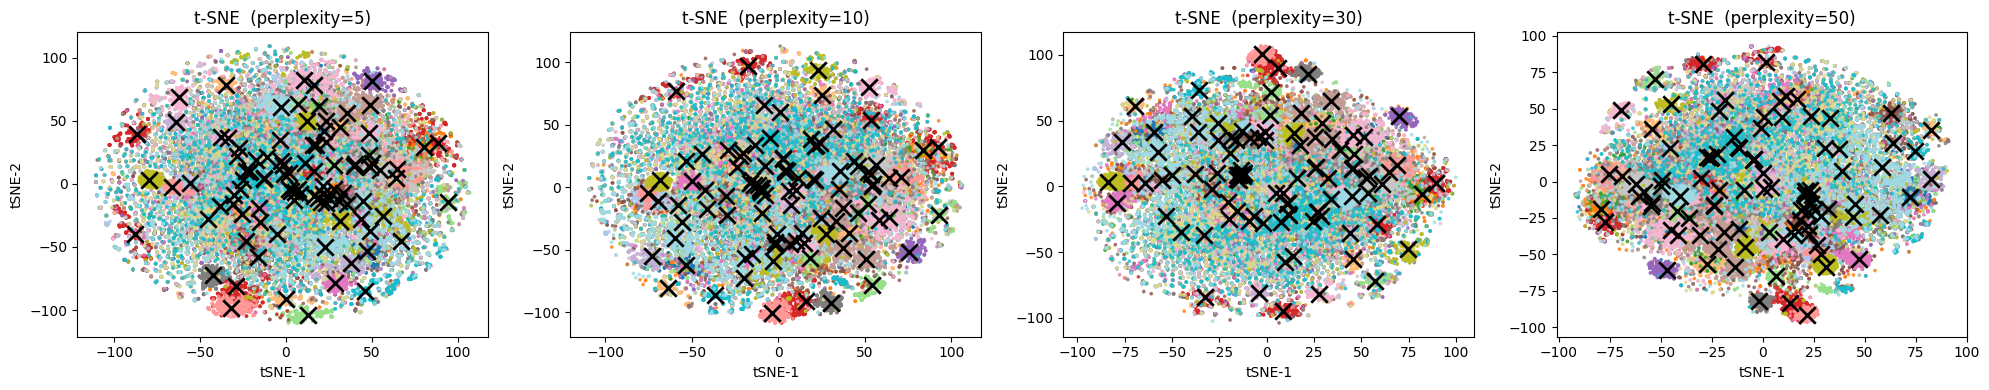

In [11]:
tsne_compare_perplexities(X, labels, centroids,
    perplexities=(5, 10, 30, 50),
    metric="cosine",                # good for embedding-like features
    max_points_per_cluster=400,
    n_iter=1000, early_exaggeration=12, learning_rate="auto",
    standardize=False, seed=0)

In [ ]:
# Run 2 stage decoding with the k-means with different # clusters.
# Report findings where X axis is the top-k that we are considering and Y axis is the recall value
# Overlay different curves based on the split that we introduce in the first step.
# This is a top-k(matmul) problem, so we fix the results of one model only.
# Might be worth considering the splits in terms of bits that are loaded instead of how many clusters we keep, because that is what we want to ultimately minimize.

In [8]:
vals, idx = labels.sort()

In [14]:
K

10000

In [15]:
avg_distance_intra = []
size = 10_000
for _ in range(size):
    class_id=np.random.randint(K)
    subset = idx[vals == class_id]
    chosen = np.random.choice(subset, 2)
    
    avg_distance_intra.append( (X[chosen[0]] @ X[chosen[1]]).item())

In [16]:
avg_distance_intra = []
size = 10_000
for _ in range(size):
    class_id=np.random.randint(K)
    subset = idx[vals == class_id]
    chosen = np.random.choice(subset, 2)
    avg_distance_intra.append( (X[chosen[0]] @ X[chosen[1]]).item())



In [17]:
avg_distance_inter = []
size = 10_000
for _ in range(size):
    c1, c2 = np.random.choice(K, 2, replace=False)
    subset1, subset2 = idx[vals == c1], idx[vals == c2]
    chosen1, chosen2 = np.random.choice(subset1, 1).squeeze(), np.random.choice(subset2, 1).squeeze()
    avg_distance_inter.append( (X[chosen1] @ X[chosen2]).item())

(0.0, 1.0)

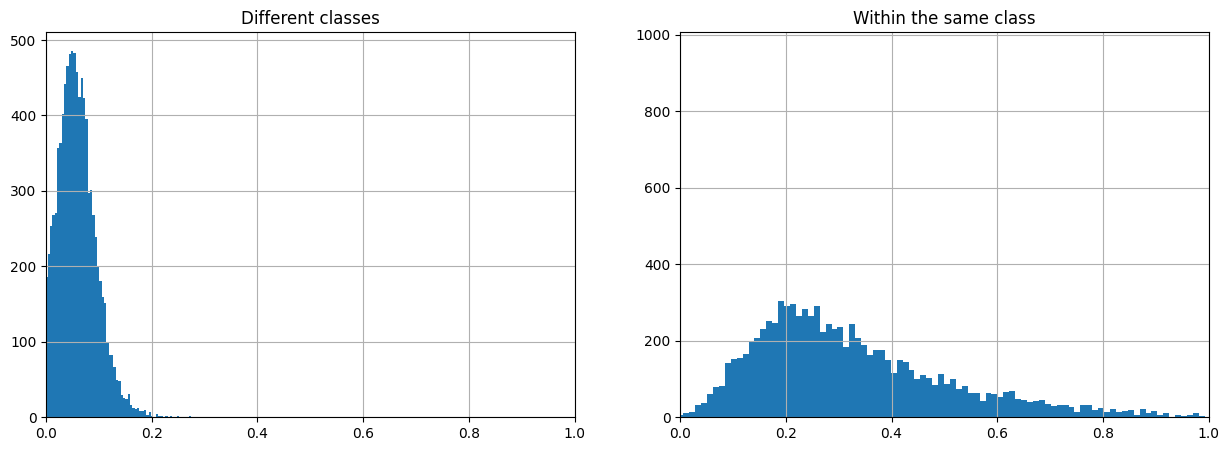

In [23]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.grid()
plt.title("Different classes")
plt.hist(avg_distance_inter, bins=100);
plt.xlim((0, 1))
plt.subplot(1,2,2)
plt.grid()
plt.title("Within the same class")
plt.hist(avg_distance_intra, bins=100);
plt.xlim((0, 1))

In [73]:
chosen1, chosen2, vals[idx == chosen1.item()], vals[idx == chosen2.item()], c1, c2

(array(150043), array(153363), tensor([153]), tensor([268]), 153, 268)

In [30]:
X.shape

torch.Size([262144, 1152])

In [12]:
pretty_list(tokenizer.batch_decode(idx[vals == 15].unsqueeze(1)))

[' не', ' without', 'not', ' never', ' नहीं', ' না', ' cannot', ' nothing',
 ' NOT', 'ない', ' None', ' nicht', ' isn', ' não', ' nie', ' none', ' कोई',
 ' không', '没有', ' couldn', 'None', 'none', ' tidak', ' نہ', ' haven',
 ' wouldn', ' dont', '不是', 'neq', ' نہیں', ' unable', ' neither', 'ません',
 ' niet', ' menos', 'なく', ' Never', 'ല്ല', 'NOT', ' নাই', '不能', ' নেই', ' 없',
 ' 않', ' নয়', 'ไม่', ' shouldn', ' ikke', ' কোনো', ' hardly', ' नाही', ' nada',
 '不会', '沒有', ' keine', ' nobody', ' ไม่', ' அல்ல', ' बिना', '不要', '不可', ' нет',
 ' کوئی', ' কোনও', 'ില്ല', ' არ', 'belum', ' nunca', 'なかった', 'without', ' নয়',
 '无法', 'Never', ' chưa', ' 아니', ' غير', ' jamais', ' Não', ' లే', ' nowhere',
 'いない', ' ain', '不到', 'ಿಲ್ಲ', 'ありません', '不知道', ' geen', 'notin', 'வில்லை',
 ' kein', '不得', ' nije', ' δεν', 'Nothing', ' नही', ' rien', ' yok', ' bukan',
 ' இல்ல', ' 못', 'らない', ' nahi', ' गैर', ' aucun', 'হীন', ' دون', '并不', ' হয়নি',
 ' ningún', ' નથી', ' unavailable', ' இல்லை', 'なし', ' belum', ' ні', '不用',
 

In [27]:
pretty_list(tokenizer.batch_decode(idx[vals == 10].unsqueeze(1)))

['<table>', '<th>', '<td>', '</tr>', '<s>', '<a>', '<html>', '<body>', '<span>',
 '<ul>', '<li>', '<div>', '<footer>', '</html>', '</body>', '</img>', '</ul>',
 '</iframe>', ' <', '//', '="', '</', ' //', '->', '==', ' ==', '##', '://',
 ' </', ' =>', '::', '><', ' >', "['", ' */', '++', ' />', '{~', "='", '></',
 '={', './', '```', ' &&', ' !=', ' []', ' <<', ' +=', '[]', ' ->', ' ||', '/*',
 '["', ' /**', '%%', ' :=', ' ===', '../', ' <-', '._', ' []:', ' **', '/>',
 '/**', ' [%', ' /*', '<<', '!--', '="#', ' <=', '*/', ' >=', '>>', '++;', '%;',
 ' ^', '[:', '<?', ' >>', ' {}', ' ::', '="/', '=(', '.</', '=>', '>();', '.*',
 ' <!--', '@@', ' {@', '.[', '>,', '=-', '<!--', ' ##', ' !==', '>=', ' ++',
 ' [];', '.__', '.~', '=[', ' %>', ';&', '?>', '///', ' -=', '?:', '<<"', '{"',
 '{{', '：“', ' @@', ' [[', '=""', '="">', '{}', '<-', ':-', '>{', ' %>%', '||',
 " {'", '="$', ' {};', '-%', ' ?>', '_.', '>=</', '.*;', ' [],', '[-', '{-',
 '={{', '={<', '/.', '?[', '&&', '@[', ' ??', '<>();

In [25]:
pretty_list(tokenizer.batch_decode(idx[vals == 4].unsqueeze(1)))

[' Mary', ' Carol', ' Mrs', ' Maria', ' Elizabeth', ' Ms', ' Jane', ' Victoria',
 ' Sarah', ' Anne', ' Jenn', ' Anna', ' Kath', 'Rober', ' Jess', ' Marie',
 ' Grace', ' Barbara', ' Laura', ' Kate', ' Margaret', ' Lisa', ' Frances',
 ' Ana', ' Susan', ' Alice', ' Charlotte', ' Nancy', ' Jennifer', ' Amy',
 ' Emily', ' Rachel', 'Mary', ' Karen', ' Beth', ' Catherine', ' Emma', ' Eve',
 ' Sue', ' Linda', ' Helen', ' Andrea', 'Mrs', ' Ruth', ' Julia', ' Sara',
 ' Michelle', ' Jessica', ' Liz', ' Lucy', ' María', ' Caroline', ' Rosa',
 ' Diana', ' Julie', ' Claire', ' Rebecca', ' Martha', ' Lauren', ' Nicole',
 ' Lynn', ' Patricia', ' Joyce', ' Ellen', ' Angela', ' Joan', ' Sally',
 ' Ashley', ' Amanda', ' Isabel', ' Annie', ' Eva', ' Louise', ' Christine',
 ' Katie', ' Betty', ' Miranda', ' Sandy', ' Hannah', ' Sophie', ' Sharon',
 ' Clara', ' Teresa', ' Janet', ' Bella', ' Jill', ' Monica', ' Donna',
 ' Amber', ' Marion', ' Holly', 'Maria', ' Lily', ' Jenny', ' Heather',
 ' Stephanie', ' 

In [24]:
pretty_list(tokenizer.batch_decode(idx[vals == 20].unsqueeze(1)))

[' blood', ' COVID', ' cancer', ' vacc', ' sympt', ' pandemic', ' bacter',
 ' radiation', ' virus', ' symptoms', ' pregn', 'abetes', ' infection',
 ' infect', ' cyt', ' immun', ' Covid', ' diabetes', ' immune', ' breast',
 ' coronavirus', ' lymph', ' neuro', ' vaccine', ' chronic', ' lung', ' neur',
 ' tumor', ' pregnancy', ' Liver', ' Cancer', ' epid', ' HIV', ' infections',
 ' syndrome', ' neural', ' arter', ' antibody', ' viral', ' disability',
 ' inflammation', ' mamm', 'ascular', ' embry', ' fever', ' antibodies',
 ' vascular', ' metabolic', ' carcin', ' bacterial', ' insulin', ' pneum',
 ' kidney', ' cardiac', ' respiratory', ' lact', ' trauma', ' transplant',
 ' adip', ' Immun', ' vaccines', ' antigen', ' massage', ' vaccination',
 ' allerg', ' metast', ' neurons', ' mening', ' urine', ' Neuro', ' arth',
 ' renal', 'infect', ' gland', 'monary', ' implant', ' fracture', ' hypert',
 ' viruses', ' hormone', ' addiction', ' hepat', ' tumors', ' bleeding',
 ' inflammatory', ' intesti

In [1]:


pretty_list(tokenizer.batch_decode(idx[vals == 55].unsqueeze(1)))

NameError: name 'pretty_list' is not defined

# Two Stage Decoding

In [5]:
import math
import torch
from typing import Optional, Tuple, List, Dict, Literal

# ----------------------------
# Helpers
# ----------------------------

@torch.no_grad()
def precompute_centroid_dist2(C1: torch.Tensor, C2: torch.Tensor) -> torch.Tensor:
    """
    Return pairwise squared distances D2: (K1, K2).
    """
    C1 = C1.float()
    C2 = C2.float()
    c1n = (C1**2).sum(1, keepdim=True)         # (K1,1)
    c2n = (C2**2).sum(1).unsqueeze(0)          # (1,K2)
    D2  = c1n + c2n - 2.0 * (C1 @ C2.T)        # (K1,K2)
    return D2.clamp_min_(0)

@torch.no_grad()
def _postings(labels: torch.Tensor, K: int) -> List[torch.Tensor]:
    # CPU long tensors of indices per cluster
    labs = labels.to("cpu")
    out: List[torch.Tensor] = []
    for k in range(K):
        idx = (labs == k).nonzero(as_tuple=False).flatten()
        out.append(idx)
    return out

@torch.no_grad()
def _scores_to_probs(scores: torch.Tensor, temperature: float = 1.0) -> torch.Tensor:
    # scores: (Q, K). returns probs: (Q, K)
    z = scores / max(1e-8, temperature)
    z = z - z.max(dim=-1, keepdim=True).values
    return torch.softmax(z, dim=-1)

@torch.no_grad()
def _centroid_scores(
    Q: torch.Tensor, C: torch.Tensor, metric: Literal["dot","euclidean"]="dot"
) -> torch.Tensor:
    # Q: (Q,D), C:(K,D) -> (Q,K)
    if metric == "dot":
        return Q @ C.T
    elif metric == "euclidean":
        qn = (Q**2).sum(dim=1, keepdim=True)      # (Q,1)
        cn = (C**2).sum(dim=1).unsqueeze(0)       # (1,K)
        d2 = qn + cn - 2.0 * (Q @ C.T)            # (Q,K)
        return -d2                                # higher = better
    else:
        raise ValueError("metric must be 'dot' or 'euclidean'")

@torch.no_grad()
def _keep_clusters(
    probs: torch.Tensor,                     # (Q,K)
    mode: Literal["abs","topm","topp"]="topp",
    thr: float = 0.9,                        # abs: prob>=thr | topm: m | topp: mass
    per_query: bool = True
) -> List[torch.Tensor]:
    """
    Returns a list length Q of 1D LongTensors of kept cluster ids.
    - abs: keep {k | p>=thr}
    - topm: keep top-m clusters (thr interpreted as m)
    - topp: smallest set whose cumulative prob >= thr
    """
    Qn, K = probs.shape
    kept: List[torch.Tensor] = []
    if mode == "abs":
        for q in range(Qn):
            kept.append((probs[q] >= thr).nonzero(as_tuple=False).flatten().cpu())
    elif mode == "topm":
        m = int(thr)
        m = max(1, min(m, K))
        vals, idx = torch.topk(probs, k=m, dim=1)
        for q in range(Qn):
            kept.append(idx[q].cpu())
    elif mode == "topp":
        # sort desc and take minimal prefix reaching mass thr
        vals, idx = torch.sort(probs, dim=1, descending=True)
        csum = vals.cumsum(dim=1)
        for q in range(Qn):
            m = (csum[q] >= thr).nonzero(as_tuple=False)
            m = (m[0,0].item() + 1) if m.numel() > 0 else K
            kept.append(idx[q, :m].cpu())
    else:
        raise ValueError("mode must be 'abs'|'topm'|'topp'")
    return kept

@torch.no_grad()
def precompute_centroid_compat(
    C1: torch.Tensor,                  # (K1, D) on device
    C2: torch.Tensor,                  # (K2, D) on device
    compat: Literal["cos", "rbf"] = "cos",
    rbf_sigma: float = 1.0,
) -> torch.Tensor:
    """
    Returns C12: (K1, K2) in [0,1], where larger = more compatible.
      - cos : C12 = (1 + cos(C1_i, C2_j)) / 2  ∈ [0,1]
      - rbf : C12 = exp( -||C1_i - C2_j||^2 / (2*sigma^2) )
    """
    if compat == "cos":
        C1n = torch.nn.functional.normalize(C1, dim=1)
        C2n = torch.nn.functional.normalize(C2, dim=1)
        C12 = (C1n @ C2n.T).clamp(-1, 1)
        C12 = 0.5 * (C12 + 1.0)  # map [-1,1] -> [0,1]
        return C12.to(torch.float32)
    else:
        # rbf (Gaussian) on L2
        c1n = (C1**2).sum(1, keepdim=True)        # (K1,1)
        c2n = (C2**2).sum(1, keepdim=True).T      # (1,K2)
        D2  = c1n + c2n - 2.0 * (C1 @ C2.T)       # (K1,K2)
        C12 = torch.exp(-D2 / (2.0 * (rbf_sigma**2) + 1e-8))
        return C12.to(torch.float32)

# ----------------------------
# Main class
# ----------------------------

class TwoStageClusterDecoder:
    """
    Holds two K-means partitions (K1, K2) over items X (N,D), and provides:
      1) centroid/label access
      2) p(cluster | query) for either partition
      3) thresholding + optional re-routing
      4) aggregated token probabilities across both partitions
      5) recall@k evaluation
    """

    def __init__(
        self,
        X: torch.Tensor,                  # (N,D) item/token representations
        C1: torch.Tensor, L1: torch.Tensor,  # (K1,D), (N,)
        C2: torch.Tensor, L2: torch.Tensor,  # (K2,D), (N,)
        device: Optional[str] = None,
    ):
        dev = torch.device(device) if device else (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
        self.X = X.to(dev, non_blocking=True).float()
        self.C1 = C1.to(dev, non_blocking=True).float()
        self.C2 = C2.to(dev, non_blocking=True).float()
        self.L1 = L1.to("cpu")
        self.L2 = L2.to("cpu")
        self.dev = dev
        self.C12 = precompute_centroid_compat(self.C1, self.C2)
        self.C12_D2 = precompute_centroid_dist2(self.C1, self.C2).to(self.dev)  # (K1,K2)

        # postings on CPU
        self.post1 = _postings(self.L1, self.C1.shape[0])
        self.post2 = _postings(self.L2, self.C2.shape[0])

        self.N, self.D = X.shape
        self.K1 = self.C1.shape[0]
        self.K2 = self.C2.shape[0]

    # -------- Step 2: p(cluster | q, C) --------
    @torch.no_grad()
    def cluster_probs(
        self, Q: torch.Tensor, which: int = 1,
        metric: Literal["dot","euclidean"]="dot",
        temperature: float = 1.0,
    ) -> torch.Tensor:
        Qd = Q.to(self.dev, non_blocking=True).float()
        C = self.C1 if which == 1 else self.C2
        s = _centroid_scores(Qd, C, metric=metric)     # (Q,K)
        return _scores_to_probs(s, temperature=temperature)

    # -------- Step 3: threshold + (optional) re-route --------
    @torch.no_grad()
    def filter_clusters(
        self, probs: torch.Tensor,
        mode: Literal["abs","topm","topp"]="topp",
        thr: float = 0.9
    ) -> List[torch.Tensor]:
        return _keep_clusters(probs, mode=mode, thr=thr)

    # -------- Step 4: aggregate to token probabilities --------
    @torch.no_grad()
    def aggregate_token_scores(
        self,
        Q: torch.Tensor,                           # (Q,D)
        p1: Optional[torch.Tensor]=None,           # (Q,K1) or None (compute)
        p2: Optional[torch.Tensor]=None,           # (Q,K2) or None (compute)
        metric: Literal["dot","euclidean"]="dot",
        beta: float = 1.0,                         # temperature for per-cluster softmax
        cap_per_cluster: Optional[int] = None,     # score only top-t items in each cluster (by quick dot with centroid)
        intersect_mask_from_C1: Optional[List[torch.Tensor]] = None,  # optional mask restricting C2 items
        progress: bool = False,
    ) -> torch.Tensor:
        """
        Returns per-query token scores (logits) of shape (Q, N) as a dense tensor on self.dev.
        Formula:
          scores_t = sum_k p1[k] * softmax(beta * q·X_{C1k})_t + sum_j p2[j] * softmax(beta * q·X_{C2j})_t
        Implementation scatters per-cluster contributions into (Q,N).
        """
        Qd = Q.to(self.dev, non_blocking=True).float()
        Qn = Qd.shape[0]
        if p1 is None: p1 = self.cluster_probs(Qd, which=1, metric=metric)
        if p2 is None: p2 = self.cluster_probs(Qd, which=2, metric=metric)

        out = torch.zeros(Qn, self.N, device=self.dev, dtype=torch.float32)

        def cluster_contrib(C, posts, probs, which_tag):
            rng = range(C.shape[0])
            if progress:
                try:
                    from tqdm import tqdm
                    rng = tqdm(rng, desc=f"clusters-{which_tag}")
                except Exception:
                    pass
            for k in rng:
                ids = posts[k]
                if ids.numel() == 0: 
                    continue
                # Optional: restrict C2 items by an intersection mask derived from C1 filtered clusters
                if which_tag == "C2" and intersect_mask_from_C1 is not None:
                    # union of allowed ids across queries (coarse but cheap)
                    allowed = torch.unique(torch.cat(intersect_mask_from_C1, dim=0)) if len(intersect_mask_from_C1)>0 else None
                    if allowed is not None:
                        # intersect ids with allowed
                        mask = torch.isin(ids, allowed)
                        ids = ids[mask]
                        if ids.numel() == 0:
                            continue

                # Optional cap: preselect top items per cluster quickly via centroid·X
                use_ids = ids
                if cap_per_cluster is not None and ids.numel() > cap_per_cluster:
                    c = C[k:k+1]  # (1,D)
                    # quick prescore by centroid similarity
                    pres = (c @ self.X[ids].to(self.dev).T).squeeze(0)  # (|ids|,)
                    take = min(cap_per_cluster, ids.numel())
                    topv, topi = torch.topk(pres, k=take)
                    use_ids = ids[topi.to("cpu")]

                Xk = self.X[use_ids.to(self.dev)]  # (M,D)
                # scores per query for items in this cluster
                S = (Qd @ Xk.T) if metric=="dot" else (-( (Qd[:,None,:]-Xk[None,:,:])**2 ).sum(dim=-1))
                # per-cluster softmax over items
                Z = S / max(1e-8, beta)
                Z = Z - Z.max(dim=1, keepdim=True).values
                P_items = torch.softmax(Z, dim=1)  # (Q, M)

                # weight by cluster prob
                w = probs[:, k].unsqueeze(1)      # (Q,1)
                contrib = w * P_items             # (Q,M)

                # scatter-add into global positions
                out.index_add_(dim=1, index=use_ids.to(self.dev), source=contrib)

        # Add contributions from both partitions
        cluster_contrib(self.C1, self.post1, p1, which_tag="C1")
        cluster_contrib(self.C2, self.post2, p2, which_tag="C2")

        return out  # (Q,N) token scores (they sum to <= 2 due to two mixtures)

    @torch.no_grad()
    def aggregate_token_scores_routed_queries_only(
        self, Q, p1, p2, keep1_mask, keep2_mask,
        metric="dot", beta=1.0, cap_per_cluster=None, progress=False
    ):
        Qd = Q.to(self.dev).float()
        Qn = Qd.shape[0]
        out = torch.zeros(Qn, self.N, device=self.dev, dtype=torch.float32)

        def process_partition(C, posts, probs, keep_mask, tag):
            rng = range(C.shape[0])
            if progress:
                try:
                    from tqdm import tqdm
                    rng = tqdm(rng, desc=f"clusters-{tag}")
                except Exception:
                    pass

            for k in rng:
                routed_rows = keep_mask[:, k].nonzero(as_tuple=False).flatten()
                if routed_rows.numel() == 0:
                    continue

                ids = posts[k]
                if ids.numel() == 0:
                    continue

                # optional cap per cluster
                use_ids = ids
                if cap_per_cluster is not None and ids.numel() > cap_per_cluster:
                    c = C[k:k+1]
                    pres = (c @ self.X[ids].to(self.dev).T).squeeze(0)
                    take = min(cap_per_cluster, ids.numel())
                    _, sel = torch.topk(pres, k=take)
                    use_ids = ids[sel.to("cpu")]

                Xk = self.X[use_ids.to(self.dev)]  # (M,D)
                Qk = Qd.index_select(0, routed_rows)  # (|Q_k|, D)

                # scores
                if metric == "dot":
                    S = Qk @ Xk.T                               # (|Q_k|, M)
                else:
                    diff = Qk[:, None, :] - Xk[None, :, :]
                    S = - (diff**2).sum(-1)

                # per-cluster softmax (row-wise)
                Z = S / max(1e-8, beta)
                Z = Z - Z.max(dim=1, keepdim=True).values
                P_items = torch.softmax(Z, dim=1)              # (|Q_k|, M)

                # weight by cluster prob
                w = probs.index_select(0, routed_rows)[:, k].unsqueeze(1)  # (|Q_k|,1)
                contrib = w * P_items                                      # (|Q_k|, M)

                # ---- Option A (simple & fast): advanced indexing add
                out[routed_rows[:, None], use_ids[None, :]] += contrib

                # ---- Option B (row index_add_): use this instead of Option A if you prefer
                # row_buf = torch.zeros(routed_rows.numel(), self.N, device=self.dev, dtype=out.dtype)
                # cols = use_ids.to(self.dev).unsqueeze(0).expand(routed_rows.numel(), -1)
                # row_buf.scatter_add_(1, cols, contrib)
                # out.index_add_(0, routed_rows, row_buf)

        process_partition(self.C1, self.post1, p1, keep1_mask, "C1")
        process_partition(self.C2, self.post2, p2, keep2_mask, "C2")
        return out


    @torch.no_grad()
    def aggregate_token_scores_routed_batched(
        self,
        Q: torch.Tensor,                              # (Q,D)
        p1: Optional[torch.Tensor] = None,            # (Q,K1)
        p2: Optional[torch.Tensor] = None,            # (Q,K2)
        keep1_mask: Optional[torch.Tensor] = None,    # (Q,K1) bool: True if query keeps cluster k
        keep2_mask: Optional[torch.Tensor] = None,    # (Q,K2) bool
        metric: Literal["dot","euclidean"] = "dot",
        beta: float = 1.0,
        cap_per_cluster: Optional[int] = None,        # pre-cap items per cluster
        progress: bool = False,
    ) -> torch.Tensor:
        """
        Fast path: iterate clusters (big GEMMs), but only let routed queries contribute.
        keep*_mask[q,k]==False -> that query's row contribution for cluster k is zeroed.
        Returns dense (Q,N) scores.
        """
        Qd = Q.to(self.dev, non_blocking=True).float()
        Qn = Qd.shape[0]
        if p1 is None: p1 = self.cluster_probs(Qd, which=1, metric=metric)  # (Q,K1)
        if p2 is None: p2 = self.cluster_probs(Qd, which=2, metric=metric)  # (Q,K2)

        # Default: everyone routes to all clusters (behaves like your original fast impl)
        if keep1_mask is None: keep1_mask = torch.ones_like(p1, dtype=torch.bool, device=self.dev)
        if keep2_mask is None: keep2_mask = torch.ones_like(p2, dtype=torch.bool, device=self.dev)

        out = torch.zeros(Qn, self.N, device=self.dev, dtype=torch.float32)

        def process_partition(C, posts, probs, keep_mask, tag: str):
            rng = range(C.shape[0])
            if progress:
                try:
                    from tqdm import tqdm
                    rng = tqdm(rng, desc=f"clusters-{tag}")
                except Exception:
                    pass
            for k in rng:
                ids = posts[k]
                if ids.numel() == 0:
                    continue

                # cap items per cluster via centroid prescore (offline shortlist would be even faster)
                use_ids = ids
                if cap_per_cluster is not None and ids.numel() > cap_per_cluster:
                    c = C[k:k+1]  # (1,D)
                    pres = (c @ self.X[ids].to(self.dev).T).squeeze(0)
                    take = min(cap_per_cluster, ids.numel())
                    _, sel = torch.topk(pres, k=take)
                    use_ids = ids[sel.to("cpu")]

                Xk = self.X[use_ids.to(self.dev)]  # (M,D)

                # Score EVERY query against this cluster ONCE (big GEMM)
                if metric == "dot":
                    S = Qd @ Xk.T                    # (Q, M)
                else:
                    diff = Qd[:, None, :] - Xk[None, :, :]
                    S = (-(diff**2).sum(-1))         # (Q, M)

                # Per-cluster softmax row-wise
                Z = S / max(1e-8, beta)
                Z = Z - Z.max(dim=1, keepdim=True).values
                P_items = torch.softmax(Z, dim=1)    # (Q, M)

                # Weight by cluster prob; zero rows that did NOT route to this cluster
                w = probs[:, k].clamp_min(0.0).unsqueeze(1)     # (Q,1)
                routed = keep_mask[:, k].unsqueeze(1)           # (Q,1) bool
                w = w * routed                                  # zeros-out non-routed queries
                contrib = w * P_items                           # (Q, M)

                # Accumulate
                out.index_add_(dim=1, index=use_ids.to(self.dev), source=contrib)

        process_partition(self.C1, self.post1, p1, keep1_mask, tag="C1")
        process_partition(self.C2, self.post2, p2, keep2_mask, tag="C2")
        return out

    # -------- Step 5: recall@k --------
    @torch.no_grad()
    def recall_of_gt_topk_in_topM(
        self,
        scores: torch.Tensor,       # (Q, N) predicted scores
        targets_topk: torch.Tensor, # (Q, Kgt) Long ground-truth indices
        ks: list[int],
        candidate_slice_length: int,
    ) -> torch.Tensor:
        Q, N = scores.shape
        kmax = max(ks)
        M = min(candidate_slice_length, N)

        # Get top-M candidate indices per query
        _, top_idx = torch.topk(scores, k=max(M, kmax), dim=1)   # (Q, max(M,kmax))
        cand = top_idx[:, :M]                                    # (Q, M)

        # Build row-wise candidate mask and test GT membership row-wise
        device = scores.device
        mask = torch.zeros(Q, N, dtype=torch.bool, device=device)
        rows = torch.arange(Q, device=device).unsqueeze(1).expand_as(cand)
        mask[rows, cand] = True                                  # mark candidates per row

        out = torch.zeros(len(ks), dtype=torch.float32, device=device)
        for i, k in enumerate(ks):
            b = targets_topk[:, :k]                              # (Q, k)
            hits = mask.gather(1, b)                             # (Q, k) bool; row-wise membership
            # recall@k = |GT@k ∩ candidates| / k (averaged over queries)
            out[i] = (hits.sum(dim=1) / k).mean()
        return out  # (len(ks),)
    @torch.no_grad()
    def precision_at_k(
        self,
        scores: torch.Tensor,       # (Q, N) predicted scores/logits
        targets_topk: torch.Tensor, # (Q, Kgt) Long ground-truth indices (from full baseline)
        ks: list[int],
    ) -> torch.Tensor:
        """
        Precision@k per k in ks, averaged over queries.
        For each query q:  precision@k = | Pred@k(q) ∩ GT@k(q) | / k
        """
        device = scores.device
        Q, N = scores.shape
        kmax = int(max(ks))

        # Predicted top-kmax indices per query
        _, pred_idx = torch.topk(scores, k=kmax, dim=1)  # (Q, kmax)

        # Build a per-row "rank map" for GT: rank[q, j] = position (1..kmax) if j in GT@kmax of row q; else kmax+1
        gt_rank = torch.full((Q, N), fill_value=kmax + 1, device=device, dtype=torch.int32)
        rows = torch.arange(Q, device=device).unsqueeze(1).expand(-1, kmax)
        gt_pos = torch.arange(1, kmax + 1, device=device, dtype=torch.int32).unsqueeze(0).expand(Q, -1)
        gt_rank[rows, targets_topk[:, :kmax]] = gt_pos  # set ranks for GT items

        # For each k: a pred is a hit iff its GT rank <= k (i.e., it's within GT@k for that row)
        out = torch.zeros(len(ks), dtype=torch.float32, device=device)
        for i, k in enumerate(ks):
            preds_k = pred_idx[:, :k]                         # (Q, k)
            hits = (gt_rank.gather(1, preds_k) <= k)          # (Q, k) bool, row-wise
            out[i] = hits.float().mean()                      # average over queries and over k
        return out  # (len(ks),)


# Init decoder
dec = TwoStageClusterDecoder(X, C1, L1, C2, L2, device=device)

NameError: name 'X' is not defined

## Dense Decode after 1 step of K-Means Heuristic Filtering

In [23]:
# 2 Stage Decoding after clarification

### Expanding Decoder columns after 1 K-Means heuristic filtering

import torch
from typing import List, Literal, Optional, Tuple

@torch.no_grad()
def centroid_routed_mask_recall(
    Q: torch.Tensor,                # (Q, D) queries
    C: torch.Tensor,                # (K, D) centroids (pick one partition)
    labels: torch.Tensor,           # (N,) Long, label of each datapoint in [0..K-1]
    X: torch.Tensor,                # (N, D) full data matrix
    m: int,                         # top-m clusters to keep (per query)
    ks: List[int],                  # k' values to test (e.g., [1,5,10,20])
    metric: Literal["dot","euclidean"] = "dot",
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Returns:
      mask:   (Q, N) bool  — True iff datapoint is in one of query's top-m clusters
      counts: (len(ks), Q) — per-k' per-query counts of how many top-k' preds fall inside the mask
      frac:   (len(ks),)   — average fraction over queries: counts[k'] / k'
    Implements:
      1) score queries vs centroids
      2) take top-m clusters per query
      3) build dense (Q,N) mask via scatter + index_select
      4) score queries vs full X and take top-k'
      5) count how many of top-k' are inside the per-row mask
    """
    dev = Q.device
    Qd = Q.float()
    Cd = C.to(dev).float()
    Xd = X.to(dev).float()
    labels = labels.to(dev, non_blocking=True).long()

    Qn, D = Qd.shape
    K = Cd.shape[0]
    N = Xd.shape[0]
    m = min(m, K)
    kmax = int(max(ks))

    # 1) query–centroid scores
    if metric == "dot":
        S_cent = Qd @ Cd.T                                 # (Q, K)
    else:
        qn = (Qd**2).sum(1, keepdim=True)                  # (Q,1)
        cn = (Cd**2).sum(1).unsqueeze(0)                   # (1,K)
        S_cent = -(qn + cn - 2.0 * (Qd @ Cd.T))            # (Q,K), negative L2

    # 2) top-m clusters per query
    topm_idx = torch.topk(S_cent, k=m, dim=1).indices      # (Q, m)

    # 3) build dense (Q,N) mask
    #    allow[i, k] = True if k is one of query i's top-m clusters
    allow = torch.zeros(Qn, K, dtype=torch.bool, device=dev)
    rows = torch.arange(Qn, device=dev).unsqueeze(1).expand_as(topm_idx)
    allow[rows, topm_idx] = True                           # set allowed clusters per query
    #    mask[i, j] = allow[i, labels[j]]
    mask = allow.index_select(1, labels)                   # (Q, N) bool

    # 4) full scores and top-k predictions
    if metric == "dot":
        S_full = Qd @ Xd.T                                 # (Q, N)
    else:
        # compute efficiently: ||q||^2 + ||x||^2 - 2 q·x
        qn = (Qd**2).sum(1, keepdim=True)                  # (Q,1)
        xn = (Xd**2).sum(1).unsqueeze(0)                   # (1,N)
        S_full = -(qn + xn - 2.0 * (Qd @ Xd.T))            # (Q,N)
    # pred_top = torch.topk(S_full, k=kmax, dim=1).indices   # (Q, kmax)
    pred_top = gt_idx   # (Q, kmax)

    # 5) per-k' counts and average fraction
    counts = torch.zeros(len(ks), Qn, device=dev, dtype=torch.int32)
    frac   = torch.zeros(len(ks), device=dev, dtype=torch.float32)
    for i, k in enumerate(ks):
        A = pred_top[:, :k]                                # (Q, k)
        # row-wise membership: mask[i, A[i, :]]
        hits = mask.gather(1, A).to(torch.int32)           # (Q, k)
        counts[i] = hits.sum(dim=1)                        # (Q,)
        frac[i]   = (counts[i].float() / float(k)).mean()  # scalar

    return mask, counts, frac

def plot_recall_vs_k(results, ks, m_values, clustering_label="Clustering"):
    """
    results: list of shape (len(m_values), len(ks))
             each row = recalls for one m setting, across ks
    ks:      list of k values used for recall (e.g., [1,5,10,20,50,100])
    m_values: list of str, labels for the m choices (e.g., ["1", "2%", "4%", ...])
    clustering_label: label prefix for the legend
    """
    res = np.array(results)  # (M, len(ks))

    fig, ax = plt.subplots(figsize=(8,6))
    for i, m_label in enumerate(m_values):
        ax.plot(ks, res[i], marker="o", label=m_label)

    ax.set_xscale("log")  # optional if ks span wide (1,5,100,…)
    ax.set_xticks(ks)
    ax.set_xticklabels([str(k) for k in ks])
    ax.set_xlabel("k (recall of GT top k)")
    ax.set_ylabel("Recall")
    ax.set_title(f"Recall@k for different kept-cluster fractions ({clustering_label})")
    ax.legend(
        loc="center right",            # anchor point is the left center of the legend
        bbox_to_anchor=(1.5, 0.5),  # move it outside the axes (x=-0.25 relative to plot)
        frameon=False
    )
    ax.grid(True, linestyle="--", alpha=0.6)
    # plt.tight_layout()
    plt.show()


In [127]:
m1 = [1,  1,  2,   5,  10,  20,  25]
m2 = [1, 20, 40, 100, 200, 400, 500]

fracs = []
masks = []
for mm1 in m1:
    mask, counts, frac = centroid_routed_mask_recall(
        Q=Q, C=dec.C1, labels=dec.L1, X=dec.X,
        m=mm1, ks=[1,5,10,20,50,100, 500], metric="dot"
    )
    fracs.append(frac.tolist())
    masks.append(mask.float().sum(dim=1).mean().item())
for mm2 in m2:
    mask, counts, frac = centroid_routed_mask_recall(
        Q=Q, C=dec.C2, labels=dec.L2, X=dec.X,
        m=mm2, ks=[1,5,10,20,50,100, 500], metric="dot"
    )
    fracs.append(frac.tolist())
    masks.append(mask.float().sum(dim=1).mean().item())



In [135]:
mask, counts, frac = centroid_routed_mask_recall(
        Q=Q, C=dec.C2, labels=dec.L2, X=dec.X,
        m=1, ks=[1,5,10,20,50,100, 500], metric="dot"
    )

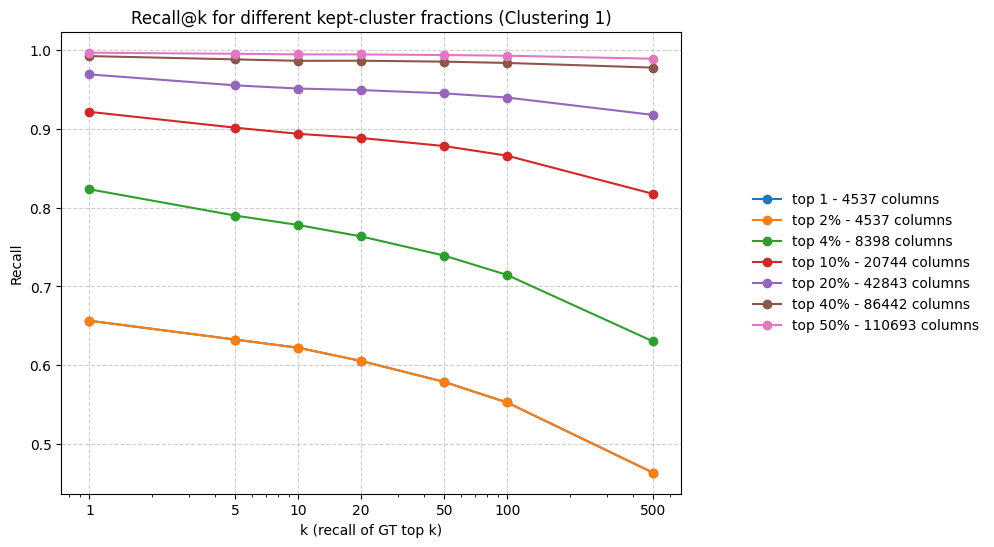

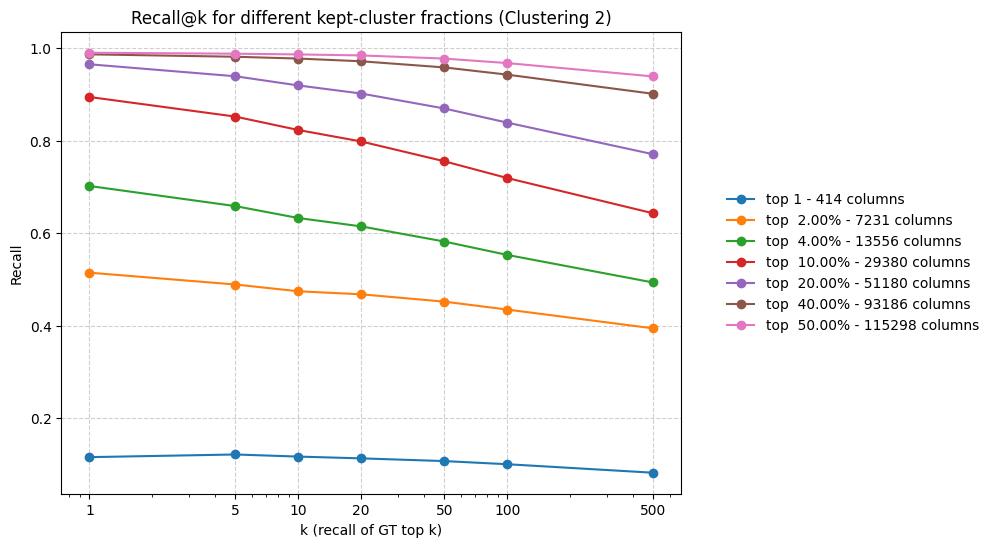

In [157]:
ks=[1,5,10,20,50,100, 500]
legend_labels =[
    'top 1',
    *[f'top {2*i}%' for i in m1[1:]],
    'top 1',
    *[f'top {i / 10 : .2f}%' for i in m2[1:]],

]
legend_labels = [f"{l} - {int(kept)} columns" for l,kept in zip(legend_labels, masks)]
plot_recall_vs_k(fracs[       :len(m1)], ks=ks, m_values=legend_labels[       :len(m1)], clustering_label="Clustering 1")
plot_recall_vs_k(fracs[len(m1):       ], ks=ks, m_values=legend_labels[len(m1):       ], clustering_label="Clustering 2")
# plot_recall_vs_k(fracs[7:9], ks=ks, m_values=legend_labels[7:9])
# plot_recall_vs_k(fracs[8:9], ks=ks, m_values=legend_labels[8:9])

(array([  5.,  53., 134., 214., 334., 439., 482., 490., 488., 418., 316.,
        203., 188., 115.,  62.,  22.,  19.,   2.,   8.,   3.,   1.,   1.,
          2.,   0.,   1.]),
 array([104348.  , 105739.16, 107130.32, 108521.48, 109912.64, 111303.8 ,
        112694.96, 114086.12, 115477.28, 116868.44, 118259.6 , 119650.76,
        121041.92, 122433.08, 123824.24, 125215.4 , 126606.56, 127997.72,
        129388.88, 130780.04, 132171.2 , 133562.36, 134953.52, 136344.68,
        137735.84, 139127.  ]),
 <BarContainer object of 25 artists>)

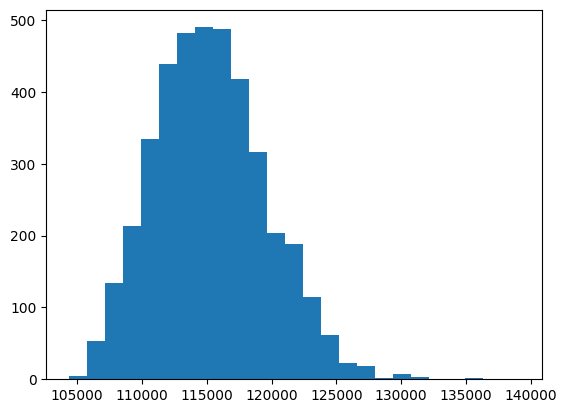

In [126]:
plt.hist(mask.sum(dim=1).detach().cpu().numpy(), bins=25)

In [136]:
mask.sum(dim=1)

tensor([913,  21, 326,  ...,  89,  89, 129], device='cuda:3')

## Sparse Aggregation from 2 Clusters

In [9]:
@torch.no_grad()
def compat_from_dist2(D2: torch.Tensor, sigma: float) -> torch.Tensor:
    """
    RBF compat in [0,1]: exp( - ||c1 - c2||^2 / (2*sigma^2) ), (K1,K2)
    """
    denom = 2.0 * (sigma * sigma) + 1e-8
    return torch.exp(-D2 / denom)

@torch.no_grad()
def auto_sigma_from_dist2(D2: torch.Tensor) -> float:
    """
    Pick sigma as the median centroid distance (not squared).
    """
    med = torch.quantile(D2.flatten(), 0.5).sqrt().item()
    return max(med, 1e-8)

@torch.no_grad()
def adjust_gates(p: torch.Tensor, tau_g: float, rho: float) -> torch.Tensor:
    """
    Temperature + power on gates, then renormalize per row:
      p' ∝ p^{1/τg}, then (p')^{ρ}, renorm.
    """
    p = p.clamp_min(1e-12)
    if tau_g != 1.0:
        p = p.pow(1.0 / tau_g)
        p = p / p.sum(dim=1, keepdim=True)
    if rho != 1.0:
        p = p.pow(rho)
        p = p / p.sum(dim=1, keepdim=True)
    return p

@torch.no_grad()
def overlap_at_k_from_scores(scores: torch.Tensor, gt_topk: torch.Tensor, ks: list[int]) -> torch.Tensor:
    Q, N = scores.shape
    kmax = int(max(ks))
    _, pred = torch.topk(scores, k=kmax, dim=1)               # (Q, kmax)
    out = torch.zeros(len(ks), device=scores.device, dtype=torch.float32)
    for i, k in enumerate(ks):
        A = pred[:, :k]                                       # (Q,k)
        B = gt_topk[:, :k]                                    # (Q,k)
        mask = torch.zeros(Q, N, dtype=torch.bool, device=scores.device)
        rows = torch.arange(Q, device=scores.device).unsqueeze(1).expand_as(A)
        mask[rows, A] = True
        hits = mask.gather(1, B).float().mean(dim=1)          # per-row
        out[i] = hits.mean()
    return out

@torch.no_grad()
def coverage_gt_topk_in_topM(scores: torch.Tensor, gt_topk: torch.Tensor, ks: list[int], M: int) -> torch.Tensor:
    Q, N = scores.shape
    M = min(M, N)
    _, cand = torch.topk(scores, k=M, dim=1)                  # (Q,M)
    mask = torch.zeros(Q, N, dtype=torch.bool, device=scores.device)
    rows = torch.arange(Q, device=scores.device).unsqueeze(1).expand_as(cand)
    mask[rows, cand] = True
    out = torch.zeros(len(ks), device=scores.device, dtype=torch.float32)
    for i, k in enumerate(ks):
        b = gt_topk[:, :k]
        hits = mask.gather(1, b).float().mean(dim=1)
        out[i] = hits.mean()
    return out


In [29]:
@torch.no_grad()
def grid_search_centroid_proxy(
    decoder, Q,
    ks=[1,5,10,20],
    alphas=[0.25,0.5,0.75],
    rhos=[0.75,1.0,1.25],
    tau_gs=[0.75,1.0,1.5],
    gammas=[0.0,0.2,0.4],
    sigmas=None,
    metric="dot", norm="zscore", tau1=1.0, tau2=1.0,
    eval_mode="overlap", topM=None,
    include_plain=True,      # <-- new
):
    dev = decoder.dev
    Qd  = Q.to(dev).float()
    K1, K2 = decoder.C1.shape[0], decoder.C2.shape[0]

    # Ground-truth once
    _, gt_topk = torch.topk(Qd @ decoder.X.T, k=max(ks), dim=1)

    # Base centroid scores
    def centroid_scores(Qx, Cx):
        if metric == "dot":
            S = Qx @ Cx.T
        else:
            qn = (Qx**2).sum(1, keepdim=True)
            cn = (Cx**2).sum(1).unsqueeze(0)
            S = -(qn + cn - 2.0*(Qx @ Cx.T))
        return S

    S1 = centroid_scores(Qd, decoder.C1) / max(1e-8, tau1)
    S2 = centroid_scores(Qd, decoder.C2) / max(1e-8, tau2)
    if norm == "zscore":
        S1 = (S1 - S1.mean(1, keepdim=True)) / (S1.std(1, keepdim=True).clamp_min_(1e-8))
        S2 = (S2 - S2.mean(1, keepdim=True)) / (S2.std(1, keepdim=True).clamp_min_(1e-8))

    L1d = decoder.L1.to(dev)
    L2d = decoder.L2.to(dev)

    # Gates once
    p1_base = decoder.cluster_probs(Qd, which=1, metric=metric)
    p2_base = decoder.cluster_probs(Qd, which=2, metric=metric)

    # Sigma grid
    if sigmas is None:
        sigma_auto = torch.quantile(decoder.C12_D2.flatten(), 0.5).sqrt().item()
        sigmas = [0.5*sigma_auto, sigma_auto, 2.0*sigma_auto]

    results = {"ks": ks, "eval_mode": eval_mode, "topM": topM, "recalls": {}}
    best_per_k = [{"recall": -1.0, "config": None} for _ in ks]

    # ---------- Plain (no gates, no compat) ----------
    if include_plain:
        for a in alphas:
            scores_plain = a * S1.index_select(1, L1d) + (1.0 - a) * S2.index_select(1, L2d)
            if eval_mode == "overlap":
                rec = overlap_at_k_from_scores(scores_plain, gt_topk, ks)
            else:
                rec = coverage_gt_topk_in_topM(scores_plain, gt_topk, ks, M=topM)
            key = ("plain", a)
            results["recalls"][key] = rec.detach().cpu()
            for i, r in enumerate(rec.tolist()):
                if r > best_per_k[i]["recall"]:
                    best_per_k[i] = {"recall": r, "config": {"mode":"plain", "alpha": a}}

    # ---------- Gated (with/without compat) ----------
    for a in alphas:
        for rho in rhos:
            for tau_g in tau_gs:
                # calibrate gates
                p1 = adjust_gates(p1_base, tau_g=tau_g, rho=rho)
                p2 = adjust_gates(p2_base, tau_g=tau_g, rho=rho)
                V1 = p1 * S1
                V2 = p2 * S2
                base = a * V1.index_select(1, L1d) + (1.0 - a) * V2.index_select(1, L2d)
                # gpair for compat
                g1 = p1.index_select(1, L1d)
                g2 = p2.index_select(1, L2d)
                gpair = torch.sqrt(g1.clamp_min(0) * g2.clamp_min(0))

                for g in gammas:
                    if g == 0.0:
                        scores = base
                        key = ("gated", a, rho, tau_g, 0.0, None)
                        if eval_mode == "overlap":
                            rec = overlap_at_k_from_scores(scores, gt_topk, ks)
                        else:
                            rec = coverage_gt_topk_in_topM(scores, gt_topk, ks, M=topM)
                        results["recalls"][key] = rec.detach().cpu()
                        for i, r in enumerate(rec.tolist()):
                            if r > best_per_k[i]["recall"]:
                                best_per_k[i] = {"recall": r, "config": {"mode":"gated", "alpha":a, "rho":rho, "tau_g":tau_g, "gamma":0.0}}
                    else:
                        for s in sigmas:
                            C12 = torch.exp(-decoder.C12_D2 / (2.0*(s*s) + 1e-8))
                            comp_item = C12.index_select(0, L1d).gather(1, L2d.view(1,-1).expand(C12.size(0), -1))[0]
                            comp = (2.0*comp_item - 1.0).unsqueeze(0).expand(Qd.size(0), -1)
                            scores = base + g * gpair * comp
                            key = ("gated+compat", a, rho, tau_g, g, s)
                            if eval_mode == "overlap":
                                rec = overlap_at_k_from_scores(scores, gt_topk, ks)
                            else:
                                rec = coverage_gt_topk_in_topM(scores, gt_topk, ks, M=topM)
                            results["recalls"][key] = rec.detach().cpu()
                            for i, r in enumerate(rec.tolist()):
                                if r > best_per_k[i]["recall"]:
                                    best_per_k[i] = {"recall": r, "config": {"mode":"gated+compat","alpha":a,"rho":rho,"tau_g":tau_g,"gamma":g,"sigma":s}}

    results["best_per_k"] = best_per_k
    return results



In [32]:
res = grid_search_centroid_proxy(
    dec, Q,
    ks=[1,5,10,20,50,100],
    alphas=[0.25, 0.5, 0.75],
    rhos=[0.75, 1.0, 1.25],
    tau_gs=[0.75, 1.0, 1.5],
    gammas=[0.0, 0.2, 0.4],
    sigmas=None,
    metric="dot",
    norm="zscore",
    eval_mode="overlap",   # or "coverage"
    topM=1024,             # only if eval_mode="coverage"
    include_plain=True     # <- this makes sure the ungated baseline is tested
)

In [33]:
print("Best per k:")
for k, bp in zip(res["ks"], res["best_per_k"]):
    print(f"k={k:3d}  recall={bp['recall']:.4f}  config={bp['config']}")

Best per k:
k=  1  recall=0.0280  config={'mode': 'plain', 'alpha': 0.25}
k=  5  recall=0.0850  config={'mode': 'plain', 'alpha': 0.25}
k= 10  recall=0.1173  config={'mode': 'gated', 'alpha': 0.25, 'rho': 1.25, 'tau_g': 0.75, 'gamma': 0.0}
k= 20  recall=0.1296  config={'mode': 'plain', 'alpha': 0.25}
k= 50  recall=0.1396  config={'mode': 'plain', 'alpha': 0.25}
k=100  recall=0.1433  config={'mode': 'plain', 'alpha': 0.5}


In [28]:
print("Best per k:")
for k, bp in zip(res["ks"], res["best_per_k"]):
    print(f"k={k:3d}  recall={bp['recall']:.4f}  config={bp['config']}")

Best per k:
k=  1  recall=0.0312  config={'alpha': 0.25, 'rho': 1.0, 'tau_g': 0.75, 'gamma': 0.0, 'sigma': 0.22745558619499207}
k=  5  recall=0.0874  config={'alpha': 0.25, 'rho': 1.25, 'tau_g': 0.75, 'gamma': 0.0, 'sigma': 0.22745558619499207}
k= 10  recall=0.1185  config={'alpha': 0.25, 'rho': 1.25, 'tau_g': 0.75, 'gamma': 0.0, 'sigma': 0.22745558619499207}
k= 20  recall=0.1300  config={'alpha': 0.25, 'rho': 1.25, 'tau_g': 0.75, 'gamma': 0.0, 'sigma': 0.22745558619499207}
k= 50  recall=0.1380  config={'alpha': 0.25, 'rho': 1.0, 'tau_g': 1.5, 'gamma': 0.0, 'sigma': 0.22745558619499207}
k=100  recall=0.1361  config={'alpha': 0.25, 'rho': 0.75, 'tau_g': 1.5, 'gamma': 0.0, 'sigma': 0.22745558619499207}


In [34]:
from typing import List, Dict, Any

# @torch.no_grad()
# def recall_at_k_from_scores(scores: torch.Tensor, gt_topk: torch.Tensor, ks: List[int]) -> torch.Tensor:
#     kmax = int(max(ks))
#     _, pred_idx = torch.topk(scores, k=kmax, dim=1)
#     out = torch.zeros(len(ks), dtype=torch.float32, device=scores.device)
#     for i, k in enumerate(ks):
#         hits = torch.isin(pred_idx[:, :k], gt_topk[:, :k]).sum(dim=1).float() / float(k)
#         out[i] = hits.mean()
#     return out

@torch.no_grad()
def ablate_centroid_proxy(
    decoder,                      # TwoStageClusterDecoder (has C1,C2,L1,L2,C12, cluster_probs)
    Q: torch.Tensor,              # (Q,D)
    ks: List[int] = [1,5,10],
    alpha_list: List[float] = [0.5],
    gamma_list: List[float] = [0.0, 0.2],   # 0.0 => no compat, >0 => with compat
    gt_topk = None,
    norm: Literal["none","zscore"] = "zscore",
    metric: Literal["dot","euclidean"] = "dot",
    tau1: float = 1.0,
    tau2: float = 1.0,
) -> Dict[str, Any]:
    """
    Runs centroid-only scoring variants and reports Recall@k.
    Variants:
      A) plain (use_gates=False, gamma=0)
      B) gates only (use_gates=True, gamma=0)
      C) gates + compat (use_gates=True, gamma>0)
    Returns dict with per-variant recall tensor [len(ks), len(alpha_list), len(gamma_list_nonzero or 1)].
    """
    dev = decoder.dev
    Qd  = Q.to(dev).float()
    # Fixed GT once (full baseline)
    if gt_topk is None:
        with torch.no_grad():
            _, gt_topk = torch.topk(Qd @ decoder.X.T, k=max(ks), dim=1)

    # Precompute gates once
    p1 = decoder.cluster_probs(Qd, which=1, metric=metric)
    p2 = decoder.cluster_probs(Qd, which=2, metric=metric)

    results: Dict[str, Any] = {"ks": ks, "alphas": alpha_list, "gammas": gamma_list, "recall": {}}

    # Helper to run one configuration
    def run_conf(use_gates: bool, gamma: float, alpha: float) -> torch.Tensor:
        # centroid scores for each partition
        def centroid_scores(Qx, Cx):
            if metric == "dot":
                S = Qx @ Cx.T
            else:
                qn = (Qx**2).sum(1, keepdim=True)
                cn = (Cx**2).sum(1).unsqueeze(0)
                S = -(qn + cn - 2.0*(Qx @ Cx.T))
            return S

        S1 = centroid_scores(Qd, decoder.C1) / max(1e-8, tau1)   # (Q,K1)
        S2 = centroid_scores(Qd, decoder.C2) / max(1e-8, tau2)   # (Q,K2)

        if norm == "zscore":
            S1 = (S1 - S1.mean(1, keepdim=True)) / (S1.std(1, keepdim=True).clamp_min_(1e-8))
            S2 = (S2 - S2.mean(1, keepdim=True)) / (S2.std(1, keepdim=True).clamp_min_(1e-8))

        if use_gates:
            V1 = p1 * S1
            V2 = p2 * S2
        else:
            V1, V2 = S1, S2

        # paint over items
        L1d = decoder.L1.to(dev); L2d = decoder.L2.to(dev)
        scores1 = V1.index_select(1, L1d)  # (Q,N)
        scores2 = V2.index_select(1, L2d)  # (Q,N)
        base = alpha * scores1 + (1.0 - alpha) * scores2

        if gamma == 0.0:
            scores = base
        else:
            # compatibility boost/penalty: use precomputed decoder.C12 ∈ [0,1]
            C12 = decoder.C12  # (K1,K2)
            # fetch per-item compat: C12[L1[t], L2[t]] -> (N,)
            comp_item = C12.index_select(0, L1d).gather(1, L2d.view(1, -1).expand(C12.size(0), -1))[0]  # (N,)
            comp = (2.0 * comp_item - 1.0).unsqueeze(0).expand(Qd.size(0), -1)  # (Q,N) in [-1,1]

            if use_gates:
                g1 = p1.index_select(1, L1d)
                g2 = p2.index_select(1, L2d)
                gpair = torch.sqrt(g1.clamp_min(0) * g2.clamp_min(0))
            else:
                gpair = torch.ones_like(base)

            scores = base + gamma * gpair * comp

        return scores

    # Run variants
    # A) plain (no gates, no compat)
    rec_A = torch.zeros(len(alpha_list), len(ks), device=dev)
    for ai, a in enumerate(alpha_list):
        scores = run_conf(use_gates=False, gamma=0.0, alpha=a)
        rec_A[ai] = decoder.recall_of_gt_topk_in_topM(scores, gt_topk, ks, 10000)
    results["recall"]["plain"] = rec_A  # [len(alpha), len(ks)]

    # B) gates only (no compat)
    rec_B = torch.zeros(len(alpha_list), len(ks), device=dev)
    for ai, a in enumerate(alpha_list):
        scores = run_conf(use_gates=True, gamma=0.0, alpha=a)
        rec_B[ai] = decoder.recall_of_gt_topk_in_topM(scores, gt_topk, ks, 10000)
    results["recall"]["gated"] = rec_B

    # C) gates + compat (loop over gammas)
    rec_C = torch.zeros(len(alpha_list), len(gamma_list), len(ks), device=dev)
    for ai, a in enumerate(alpha_list):
        for gi, g in enumerate(gamma_list):
            scores = run_conf(use_gates=True, gamma=g, alpha=a)
            rec_C[ai, gi] = decoder.recall_of_gt_topk_in_topM(scores, gt_topk, ks, 10000)
    results["recall"]["gated+compat"] = rec_C

    return results


In [100]:
## Cluster compatibility visualization helpers 

import torch
import matplotlib.pyplot as plt

@torch.no_grad()
def svd_seriation(C12: torch.Tensor):
    """
    Return row and col permutations via first singular vectors.
    C12: (K1, K2) on any device/dtype.
    """
    X = C12.float().cpu()
    # Center columns a bit to reduce trivial bias
    Xc = X - X.mean(dim=0, keepdim=True)
    # low-rank SVD (torch.pca_lowrank is fine too)
    U, S, Vh = torch.linalg.svd(Xc, full_matrices=False)  # U:(K1,r), Vh:(r,K2)
    u1 = U[:, 0]; v1 = Vh[0, :]
    rperm = torch.argsort(u1)      # rows by u1
    cperm = torch.argsort(v1)      # cols by v1
    return rperm, cperm

@torch.no_grad()
def plot_c12_heatmap(C12: torch.Tensor, vmax_pct: float = 99.5, figsize=(10,5)):
    # Reorder for structure
    rperm, cperm = svd_seriation(C12)
    X = C12.float().cpu()#[rperm][:, cperm]
    # percentile clipping for contrast
    vmax = torch.quantile(X.flatten(), vmax_pct/100.0).item()
    plt.figure(figsize=figsize)
    plt.imshow(X, aspect='auto', cmap='viridis', vmin=0.0, vmax=vmax)
    plt.colorbar(label='compatibility')
    plt.xlabel('C2 clusters (reordered)')
    plt.ylabel('C1 clusters (reordered)')
    plt.title('C12 heatmap (SVD-seriated)')
    plt.tight_layout()
    plt.show()

@torch.no_grad()
def plot_c12_binned(C12: torch.Tensor, col_bins: int = 40, pool: str = "mean", figsize=(9,5)):
    """
    Sort columns by v1 (SVD), then aggregate into 'col_bins' bins using mean/max.
    """
    assert pool in {"mean","max"}
    rperm, cperm = svd_seriation(C12)
    X = C12.float().cpu()[rperm][:, cperm]   # (K1, K2)
    K1, K2 = X.shape
    # split columns into fairly equal bins
    edges = torch.linspace(0, K2, steps=col_bins+1).round().long()
    Xb = []
    for i in range(col_bins):
        a, b = edges[i].item(), edges[i+1].item()
        slab = X[:, a:b]
        if slab.numel() == 0:
            col = torch.zeros(K1, 1)
        else:
            col = slab.mean(dim=1, keepdim=True) if pool=="mean" else slab.max(dim=1, keepdim=True).values
        Xb.append(col)
    Xb = torch.cat(Xb, dim=1)  # (K1, col_bins)

    plt.figure(figsize=figsize)
    plt.imshow(Xb, aspect='auto', cmap='viridis')
    plt.colorbar(label=f'compat ({pool} per bin)')
    plt.xlabel(f'C2 (seriated + {pool} over {col_bins} bins)')
    plt.ylabel('C1 (seriated)')
    plt.title('C12 binned heatmap')
    plt.tight_layout()
    plt.show()

@torch.no_grad()
def plot_c12_topk_scatter(C12: torch.Tensor, k: int = 10, thresh: float = 0.0, figsize=(10,6)):
    """
    For each row, plot the indices of its top-k columns as a scatter.
    Point size/alpha reflects value. 'thresh' hides very small values.
    """
    X = C12.float().cpu()
    K1, K2 = X.shape
    vals, idx = torch.topk(X, k=min(k, K2), dim=1)
    # optionally filter by threshold
    mask = vals >= thresh
    xs = idx[mask]
    ys = torch.arange(K1).unsqueeze(1).expand_as(idx)[mask]
    ws = vals[mask]
    plt.figure(figsize=figsize)
    plt.scatter(xs, ys, s=(ws.numpy()*50.0), alpha=0.7, c=ws, cmap='viridis')
    plt.gca().invert_yaxis()
    plt.colorbar(label='compat value')
    plt.xlabel('C2 cluster index')
    plt.ylabel('C1 cluster index')
    plt.title(f'C12 top-{k} columns per row (threshold ≥ {thresh})')
    plt.tight_layout()
    plt.show()

@torch.no_grad()
def c12_row_summaries(C12: torch.Tensor):
    """
    Print quick stats per row: max, 2nd max, gap, entropy-ish.
    """
    X = C12.float().cpu()
    # normalize each row to sum 1 for entropy
    P = X / (X.sum(dim=1, keepdim=True) + 1e-12)
    maxv, _ = X.max(dim=1)
    top2v = torch.topk(X, k=min(2, X.shape[1]), dim=1).values
    gap = (top2v[:, 0] - (top2v[:, 1] if top2v.shape[1] > 1 else 0.0))
    H = -(P * (P.clamp_min(1e-12)).log()).sum(dim=1)
    print("Row max (median/min/max):", float(maxv.median()), float(maxv.min()), float(maxv.max()))
    print("Row gap (median/min/max):", float(gap.median()), float(gap.min()), float(gap.max()))
    print("Entropy  (median/min/max):", float(H.median()), float(H.min()), float(H.max()))


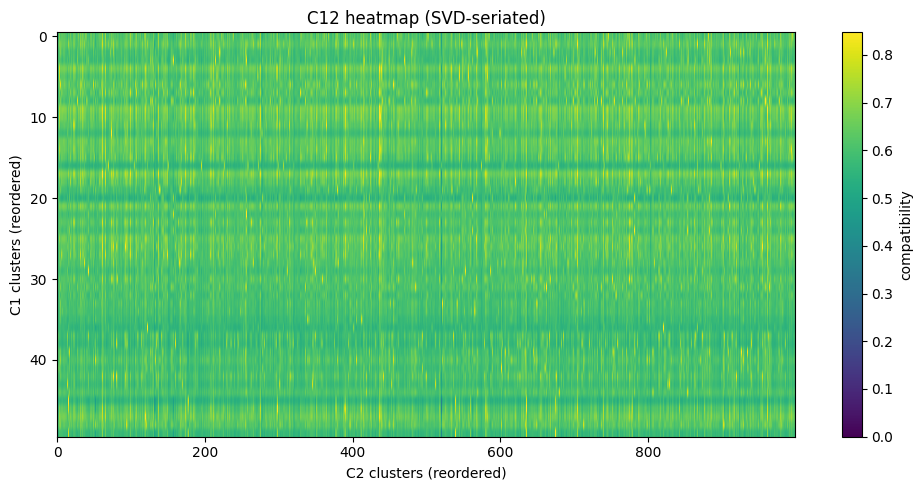

In [101]:
plot_c12_heatmap(dec.C12)


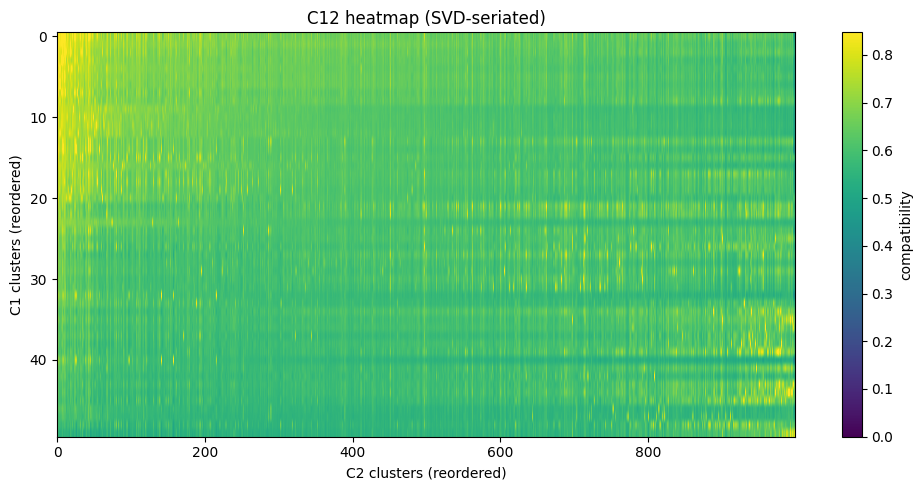

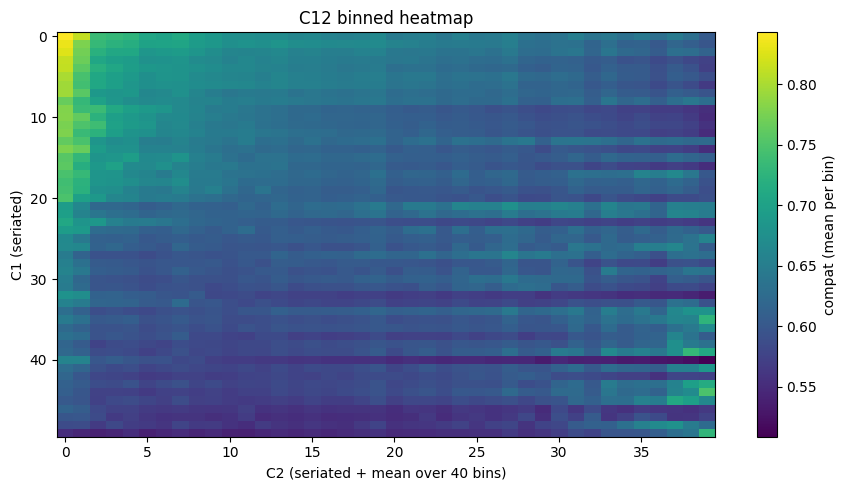

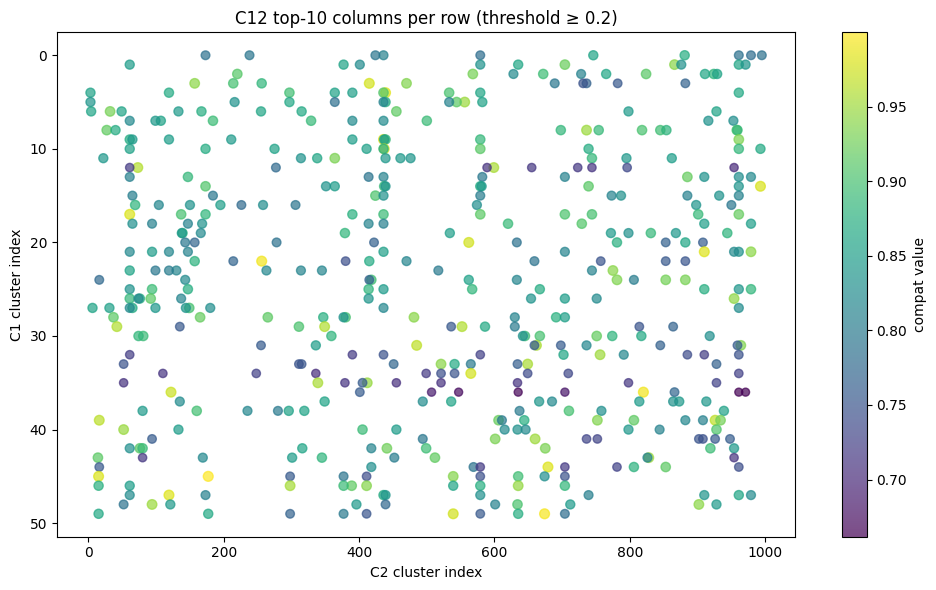

Row max (median/min/max): 0.9491363763809204 0.8581781387329102 0.9999348521232605
Row gap (median/min/max): 0.019727766513824463 9.226799011230469e-05 0.22653347253799438
Entropy  (median/min/max): 6.904869079589844 6.903266906738281 6.906301498413086


In [99]:
# Plain seriated heatmap with percentile clipping
plot_c12_heatmap(dec.C12)

# Binned version (easier read): 50×40 (mean-pooled)
plot_c12_binned(dec.C12, col_bins=40, pool="mean")

# Sparse view: top-10 columns per row
plot_c12_topk_scatter(dec.C12, k=10, thresh=0.2)

# Numeric summaries to aid interpretation
c12_row_summaries(dec.C12)


In [153]:
res = ablate_centroid_proxy(
    dec, Q, ks=[1,5,10,20,50,100,500],
    alpha_list=[0.25, 0.5, 0.75],
    gamma_list=[0.0, 0.1, 0.2, 0.4],   # gamma=0 lines up with "gated"
    norm="zscore", metric="dot"
)


NameError: name 'ablate_centroid_proxy' is not defined

In [36]:
res

{'ks': [1, 5, 10, 20, 50, 100, 500],
 'alphas': [0.25, 0.5, 0.75],
 'gammas': [0.0, 0.1, 0.2, 0.4],
 'recall': {'plain': tensor([[0.8783, 0.8021, 0.7617, 0.7194, 0.6582, 0.6125, 0.5208],
          [0.9123, 0.8413, 0.8022, 0.7615, 0.6995, 0.6516, 0.5488],
          [0.8905, 0.8383, 0.8101, 0.7795, 0.7332, 0.6935, 0.5953]],
         device='cuda:6'),
  'gated': tensor([[0.9150, 0.8708, 0.8453, 0.8167, 0.7720, 0.7369, 0.6450],
          [0.8968, 0.8528, 0.8287, 0.8013, 0.7563, 0.7219, 0.6320],
          [0.8613, 0.8223, 0.7996, 0.7739, 0.7317, 0.6990, 0.6141]],
         device='cuda:6'),
  'gated+compat': tensor([[[0.9150, 0.8708, 0.8453, 0.8167, 0.7720, 0.7369, 0.6450],
           [0.9158, 0.8716, 0.8465, 0.8183, 0.7740, 0.7390, 0.6471],
           [0.9158, 0.8721, 0.8471, 0.8190, 0.7748, 0.7396, 0.6476],
           [0.9163, 0.8724, 0.8475, 0.8196, 0.7755, 0.7404, 0.6482]],
  
          [[0.8968, 0.8528, 0.8287, 0.8013, 0.7563, 0.7219, 0.6320],
           [0.8973, 0.8538, 0.8302, 0.8032,

In [41]:
## Debugging helpers

@torch.no_grad()
def check_labels_vs_postings(dec):
    ok = True
    L1c = dec.L1.cpu(); L2c = dec.L2.cpu()
    K1 = dec.C1.shape[0]; K2 = dec.C2.shape[0]

    for k in range(K1):
        a = (L1c == k).nonzero(as_tuple=False).flatten().sort().values
        b = dec.post1[k].cpu().sort().values
        if a.numel() != b.numel() or not torch.equal(a, b):
            print(f"[C1] mismatch at k={k}: label count {a.numel()} vs post count {b.numel()}")
            ok = False
            break

    for k in range(K2):
        a = (L2c == k).nonzero(as_tuple=False).flatten().sort().values
        b = dec.post2[k].cpu().sort().values
        if a.numel() != b.numel() or not torch.equal(a, b):
            print(f"[C2] mismatch at k={k}: label count {a.numel()} vs post count {b.numel()}")
            ok = False
            break

    if ok:
        print("Labels and postings are consistent ✅")

check_labels_vs_postings(dec)


@torch.no_grad()
def check_label_ranges(dec):
    K1 = dec.C1.shape[0]; K2 = dec.C2.shape[0]
    print("L1 dtype:", dec.L1.dtype, "min/max:", int(dec.L1.min()), int(dec.L1.max()), f"expected in [0,{K1-1}]")
    print("L2 dtype:", dec.L2.dtype, "min/max:", int(dec.L2.min()), int(dec.L2.max()), f"expected in [0,{K2-1}]")
    assert dec.L1.dtype == torch.long and dec.L2.dtype == torch.long, "Labels must be torch.long"
    assert 0 <= int(dec.L1.min()) and int(dec.L1.max()) < K1, "L1 out of range"
    assert 0 <= int(dec.L2.min()) and int(dec.L2.max()) < K2, "L2 out of range"

check_label_ranges(dec)


@torch.no_grad()
def check_centroid_means(dec, sample_k=6):
    Ks = min(sample_k, dec.C1.shape[0])
    print("Checking C1 vs mean(X[post1[k]]) ...")
    for k in random.sample(range(dec.C1.shape[0]), Ks):
        ids = dec.post1[k]
        if ids.numel() == 0: 
            print(f"  C1 k={k}: empty cluster")
            continue
        mu = dec.X[ids].mean(0).to(dec.C1.device)
        rel_err = torch.norm(mu - dec.C1[k]) / (torch.norm(mu) + 1e-8)
        print(f"  C1 k={k}: rel error ≈ {rel_err.item():.3e}")
    Ks = min(sample_k, dec.C2.shape[0])
    print("Checking C2 vs mean(X[post2[k]]) ...")
    for k in random.sample(range(dec.C2.shape[0]), Ks):
        ids = dec.post2[k]
        if ids.numel() == 0:
            print(f"  C2 k={k}: empty cluster")
            continue
        mu = dec.X[ids].mean(0).to(dec.C2.device)
        rel_err = torch.norm(mu - dec.C2[k]) / (torch.norm(mu) + 1e-8)
        print(f"  C2 k={k}: rel error ≈ {rel_err.item():.3e}")

check_centroid_means(dec)


@torch.no_grad()
def probe_painting(dec, Q, metric="dot", num_items=12):
    dev = dec.dev
    Qd = Q[:1].to(dev).float()  # single query
    L1d, L2d = dec.L1.to(dev), dec.L2.to(dev)

    def cent(Qx, Cx):
        if metric == "dot":
            return Qx @ Cx.T
        qn = (Qx**2).sum(1, keepdim=True)
        cn = (Cx**2).sum(1).unsqueeze(0)
        return -(qn + cn - 2.0*(Qx @ Cx.T))

    S1 = cent(Qd, dec.C1)  # (1,K1)
    S2 = cent(Qd, dec.C2)  # (1,K2)

    P1 = S1.index_select(1, L1d)  # (1,N)
    P2 = S2.index_select(1, L2d)  # (1,N)

    N = dec.X.shape[0]
    for t in random.sample(range(N), min(num_items, N)):
        k1 = int(L1d[t]); k2 = int(L2d[t])
        v1, exp1 = float(P1[0, t]), float(S1[0, k1])
        v2, exp2 = float(P2[0, t]), float(S2[0, k2])
        ok1 = abs(v1 - exp1) < 1e-6
        ok2 = abs(v2 - exp2) < 1e-6
        print(f"t={t:7d}  k1={k1:4d}  paint1={v1:+.6f}  s1[k1]={exp1:+.6f}  ok={ok1}   "
              f"k2={k2:4d}  paint2={v2:+.6f}  s2[k2]={exp2:+.6f}  ok={ok2}")

probe_painting(dec, Q, metric="dot")


@torch.no_grad()
def plain_centroid_scores(dec, Q, alpha=0.5, metric="dot", norm="zscore", tau1=1.0, tau2=1.0):
    dev = dec.dev
    Qd = Q.to(dev).float()

    def cent(Qx, Cx):
        if metric == "dot":
            return Qx @ Cx.T
        qn = (Qx**2).sum(1, keepdim=True)
        cn = (Cx**2).sum(1).unsqueeze(0)
        return -(qn + cn - 2.0*(Qx @ Cx.T))

    S1 = cent(Qd, dec.C1) / max(1e-8, tau1)
    S2 = cent(Qd, dec.C2) / max(1e-8, tau2)
    if norm == "zscore":
        S1 = (S1 - S1.mean(1, keepdim=True)) / (S1.std(1, keepdim=True).clamp_min_(1e-8))
        S2 = (S2 - S2.mean(1, keepdim=True)) / (S2.std(1, keepdim=True).clamp_min_(1e-8))

    scores = alpha * S1.index_select(1, dec.L1.to(dev)) + (1 - alpha) * S2.index_select(1, dec.L2.to(dev))
    return scores

@torch.no_grad()
def overlap_at_k_from_scores(scores: torch.Tensor, gt_topk: torch.Tensor, ks: list[int]) -> torch.Tensor:
    Q, N = scores.shape
    kmax = int(max(ks))
    _, pred = torch.topk(scores, k=kmax, dim=1)
    out = torch.zeros(len(ks), device=scores.device, dtype=torch.float32)
    for i, k in enumerate(ks):
        A = pred[:, :k]  # (Q,k)
        B = gt_topk[:, :k]
        mask = torch.zeros(Q, N, dtype=torch.bool, device=scores.device)
        rows = torch.arange(Q, device=scores.device).unsqueeze(1).expand_as(A)
        mask[rows, A] = True
        hits = mask.gather(1, B).float().mean(dim=1)
        out[i] = hits.mean()
    return out

@torch.no_grad()
def coverage_gt_topk_in_topM(scores: torch.Tensor, gt_topk: torch.Tensor, ks: list[int], M: int) -> torch.Tensor:
    Q, N = scores.shape
    M = min(M, N)
    _, cand = torch.topk(scores, k=M, dim=1)                  # (Q,M)
    mask = torch.zeros(Q, N, dtype=torch.bool, device=scores.device)
    rows = torch.arange(Q, device=scores.device).unsqueeze(1).expand_as(cand)
    mask[rows, cand] = True
    out = torch.zeros(len(ks), device=scores.device, dtype=torch.float32)
    for i, k in enumerate(ks):
        b = gt_topk[:, :k]
        hits = mask.gather(1, b).float().mean(dim=1)
        out[i] = hits.mean()
    return out

# ---- run the metric sanity
ks_eval = [1,5,10,20]
Qd = Q.to(dec.dev).float()
# Full GT baseline once (make sure N is correct)
# _, gt_topk = torch.topk(Qd @ dec.X.to(dec.dev).T, k=max(ks_eval), dim=1)
gt_topk = gt_idx.to(device)

scores_plain = plain_centroid_scores(dec, Q, alpha=0.5, metric="dot", norm="zscore")
print("plain overlap@k:", overlap_at_k_from_scores(scores_plain, gt_topk, ks_eval).tolist())
print("plain coverage@k in topM=1024:", coverage_gt_topk_in_topM(scores_plain, gt_topk, ks_eval, M=1024).tolist())



Labels and postings are consistent ✅
L1 dtype: torch.int64 min/max: 0 49 expected in [0,49]
L2 dtype: torch.int64 min/max: 0 999 expected in [0,999]
Checking C1 vs mean(X[post1[k]]) ...
  C1 k=38: rel error ≈ 1.855e-07
  C1 k=24: rel error ≈ 9.570e-08
  C1 k=20: rel error ≈ 4.994e-08
  C1 k=36: rel error ≈ 6.135e-08
  C1 k=15: rel error ≈ 1.530e-07
  C1 k=18: rel error ≈ 1.227e-07
Checking C2 vs mean(X[post2[k]]) ...
  C2 k=188: rel error ≈ 1.775e-08
  C2 k=193: rel error ≈ 4.555e-08
  C2 k=841: rel error ≈ 6.725e-08
  C2 k=191: rel error ≈ 5.141e-08
  C2 k=33: rel error ≈ 2.014e-08
  C2 k=627: rel error ≈ 5.957e-08
t= 136344  k1=  16  paint1=-2.970266  s1[k1]=-2.970266  ok=True   k2= 603  paint2=-3.323915  s2[k2]=-3.323915  ok=True
t= 249839  k1=   1  paint1=-5.758816  s1[k1]=-5.758816  ok=True   k2=   2  paint2=-3.272082  s2[k2]=-3.272082  ok=True
t=  36220  k1=  22  paint1=+2.262639  s1[k1]=+2.262639  ok=True   k2= 256  paint2=+1.461346  s2[k2]=+1.461346  ok=True
t=  47093  k1=  22 

In [151]:
@torch.no_grad()
def routing_mask_from_probs(probs: torch.Tensor, mode="topp", thr=0.9, topm: Optional[int]=None):
    # probs: (Q,K)
    Q, K = probs.shape
    if mode == "topm":
        m = int(topm if topm is not None else thr)
        _, idx = torch.topk(probs, k=min(m, K), dim=1)
        mask = torch.zeros(Q, K, dtype=torch.bool, device=probs.device)
        rows = torch.arange(Q, device=probs.device).unsqueeze(1).expand_as(idx)
        mask[rows, idx] = True
        return mask
    else:  # topp
        vals, idx = torch.sort(probs, dim=1, descending=True)      # (Q,K)
        csum = vals.cumsum(1)
        pos = (csum >= float(thr)).int().argmax(dim=1) + 1         # (Q,) prefix length
        # build mask by marking first pos[q] columns in sorted order
        mask = torch.zeros(Q, K, dtype=torch.bool, device=probs.device)
        ar = torch.arange(K, device=probs.device).unsqueeze(0).expand_as(idx)
        take = ar < pos.unsqueeze(1)                                # (Q,K) which sorted positions to take
        rows = torch.arange(Q, device=probs.device).unsqueeze(1).expand_as(idx)
        mask[rows[take], idx[take]] = True                          # scatter back to original cluster ids
        return mask

In [152]:
## Comparing different aggregation methods

p1 = dec.cluster_probs(Q, which=1, metric="dot", temperature=0.7)
p2 = dec.cluster_probs(Q, which=2, metric="dot", temperature=0.7)

keep1 = routing_mask_from_probs(p1, mode="topp", thr=0.9)
keep2 = routing_mask_from_probs(p2, mode="topm", topm=3)
scores1 = dec.aggregate_token_scores_routed_batched(
    Q, p1=p1, p2=p2,
    keep1_mask=keep1, keep2_mask=keep2,
    metric="dot", beta=1.0, cap_per_cluster=2048,
    progress=False,
)


scores2 = dec.aggregate_token_scores_routed_queries_only(
    Q, p1=p1, p2=p2,
    keep1_mask=keep1, keep2_mask=keep2,
    metric="dot", beta=1.0, cap_per_cluster=2048,
    progress=False,
)

scores = dec.aggregate_token_scores(
    Q, p1=p1, p2=p2, metric="dot", beta=1.0,
    cap_per_cluster=2048,
    intersect_mask_from_C1=None,  # or mask_from_C1 to restrict C2’s items
    progress=False,
)

ks = [1, 5, 10, 20, 50, 100, 500]
rec = dec.recall_of_gt_topk_in_topM(scores, gt_idx.to(device), ks, 10_000)

rec

tensor([0.9965, 0.9861, 0.9807, 0.9807, 0.9765, 0.9679, 0.9315],
       device='cuda:6')

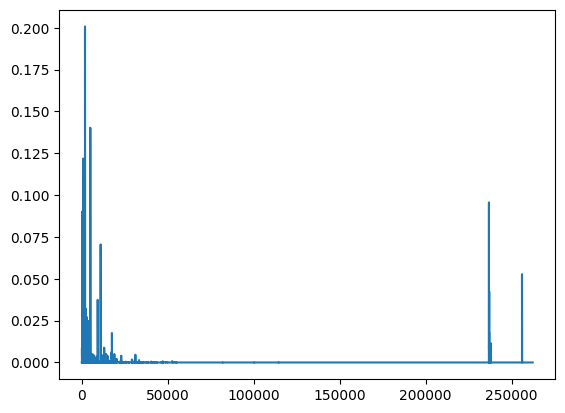

In [29]:
plt.plot(scores[0].detach().cpu().numpy())

{1: 0.9957500696182251, 5: 0.983150064945221, 10: 0.9756750464439392, 20: 0.9651375412940979, 50: 0.939560055732727, 100: 0.9081700444221497, 500: 0.7930095791816711}


# Graph Traversal Idea

In [11]:
import torch
from dataclasses import dataclass
from typing import List, Tuple, Optional

# ----- utils -----
@torch.no_grad()
def pca_rotate(M: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    # M: (N,D), columns = items
    # return R, V such that R = M @ V  (orthonormal V)
    U, S, Vh = torch.linalg.svd(M.float(), full_matrices=False)
    V = Vh.T.contiguous()
    R = M @ V
    return R, V

@dataclass
class Level:
    # centroids for this level (per parent)
    # For level 1: C shape (K1, B1)
    # For deeper levels: list per parent: [ (Ki, B_i) ]
    C: any
    # children links; for non-root, aligned with parents
    children: any
    # cached norms after current block (for UB)
    tail_norms: any
    # leaf postings only for last level
    postings: Optional[List[torch.Tensor]] = None

class TreeIndex:
    def __init__(self, blocks: List[int], k_per_level: List[int], device="cpu"):
        self.blocks = blocks
        self.k_per_level = k_per_level
        self.dev = torch.device(device)

    @torch.no_grad()
    def fit(self, M: torch.Tensor, seed: int = 0):
        self.N, self.D = M.shape
        # 0) rotate
        R, V = pca_rotate(M)                 # R on same device as M
        self.R = R.contiguous()
        self.V = V.contiguous()
        # 1..L) build levels (you’ll plug your kmeans here)
        # --- Level 1 ---
        B1 = self.blocks[0]
        K1 = self.k_per_level[0]
        C1, L1, post1 = kmeans_simple(self.R[:, :B1], K1, seed=seed)  # implement or call yours
        # tail norms for UB (optional finer bound: centroid tail + radius)
        # tail1 = self.R[:, B1:]  # not actually needed here; we’ll keep simple UB
        # C1_tail_norm = torch.linalg.norm(self.R[:, B1:], dim=1).mean() * torch.ones(K1, device=self.dev)  # placeholder
        # Store
        self.level1 = {
            "C": C1.contiguous(),           # (K1, B1)
            "post": post1,                  # list of LongTensor ids
            # "tail_norm": C1_tail_norm       # simplistic
        }
        # --- Level 2 (per parent) ---
        B2 = self.blocks[1]
        K2 = self.k_per_level[1]
        C2_list = []
        children2 = []
        tail2_list = []
        post2_list = []
        for k in range(K1):
            ids = post1[k]
            if ids.numel() == 0:
                C2_list.append(torch.empty(0, B2))
                children2.append([])
                tail2_list.append(torch.empty(0))
                post2_list.append([])
                continue
            # Xk = self.R[ids, B1:B1+B2]
            Xk = self.R[ids, :B2]
            C2, L2, post2 = kmeans_simple(Xk, K2, seed=seed+1)
            # cache postings in original ids:
            post2_global = []
            for child_ids in post2:
                post2_global.append(ids[child_ids])
            # simple tail norm placeholder
            # tail2 = torch.linalg.norm(self.R[ids][:, B1+B2:], dim=1).mean() * torch.ones(C2.shape[0])
            C2_list.append(C2.contiguous()); children2.append(list(range(C2.shape[0])))
            # tail2_list.append(tail2); 
            post2_list.append(post2_global)
        self.level2 = {
            "C_per_parent": C2_list,         # list length K1; each (K2p, B2)
            "postings_per_parent": post2_list,
            # "tail_norm_per_parent": tail2_list
        }
        # If you want a third level, repeat similarly on remaining dims.

    @torch.no_grad()
    def search(self, x: torch.Tensor, k: int, beam1: int = 8, beam2: int = 16) -> Tuple[torch.Tensor, torch.Tensor]:
        # rotate query
        x = x.to(self.R.device).float()
        xrot = x @ self.V                               # (D,)
        B1, B2 = self.blocks[:2]
        # Level 1 scores
        C1 = self.level1["C"].to(x.device)
        s1 = xrot[:B1] @ C1.T                           # (K1,)
        top1 = torch.topk(s1, k=min(beam1, s1.numel()))
        idx1 = top1.indices

        # Level 2 expansion
        cand_ids = []
        # x2 = xrot[B1:B1+B2]
        x2 = xrot[:B2]
        for p in idx1.tolist():
            C2p = self.level2["C_per_parent"][p].to(x.device)
            if C2p.numel() == 0:
                continue
            s2 = (x2 @ C2p.T) + s1[p]                  # accumulate
            idx2 = torch.topk(s2, k=min(beam2, s2.numel())).indices
            # collect postings from these leaves
            posts = self.level2["postings_per_parent"][p]
            for c2 in idx2.tolist():
                cand_ids.append(posts[c2])

        if len(cand_ids) == 0:
            return torch.empty(0, dtype=torch.long), torch.empty(0)

        CAND = torch.unique(torch.cat(cand_ids))       # Long (nC,)
        Rsub = self.R[CAND]                             # (nC, D)
        score = (xrot @ Rsub.T).contiguous()            # (nC,)
        topv, topi = torch.topk(score, k=min(k, score.numel()))
        return CAND[topi], topv

# --- stub kmeans (replace with your chunked kmeans and postings) ---
@torch.no_grad()
def kmeans_simple(X: torch.Tensor, K: int, seed: int = 0):
    # For prototyping only (uses torch.kmeans if available, else random)
    # Return C (K,D), labels (N,), postings: List[LongTensor]
    N = X.shape[0]
    K = min(K, max(1, N))
    g = torch.Generator(device="cpu").manual_seed(seed)
    idx = torch.randperm(N, generator=g)[:K]
    C = X[idx].clone()
    for _ in range(10):
        # assign
        d2 = (X**2).sum(1,keepdim=True) + (C**2).sum(1).unsqueeze(0) - 2*(X@C.T)
        labs = d2.argmin(dim=1)
        # update
        for k in range(K):
            m = (labs == k).nonzero(as_tuple=False).flatten()
            if m.numel() > 0:
                C[k] = X[m].mean(0)
    postings = []
    for k in range(K):
        postings.append((labs == k).nonzero(as_tuple=False).flatten())
    return C, labs, postings


In [232]:
X.shape, Q.shape

(torch.Size([262208, 2560]), torch.Size([4000, 2560]))

In [ ]:
plt.imshow(T.R)

In [13]:
pairwise=T.R[0:100000:10]@T.R[0:100000:10].T

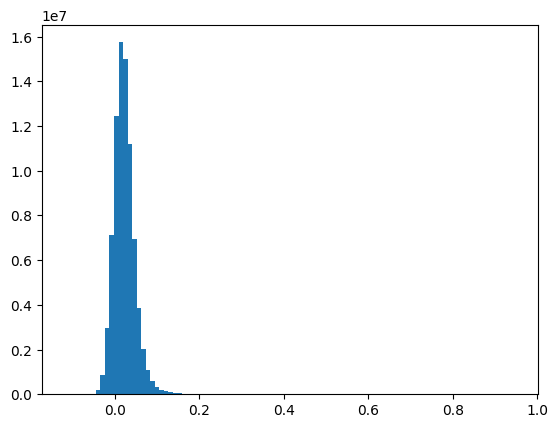

In [17]:

plt.hist(pairwise[1000:,1000:].cpu().numpy().reshape(-1),bins=100);
# plt.yscale('log')

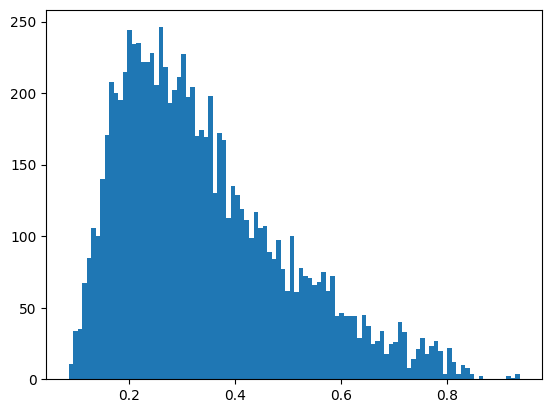

In [27]:
plt.hist(torch.topk(pairwise[1000:,1000:], k=2, dim=1, sorted=True).values[:, -1].cpu().numpy().reshape(-1),bins=100);


In [15]:
np.mean(pairwise[1000:,1000:].cpu().numpy()<-0.01)

0.06615698765432099

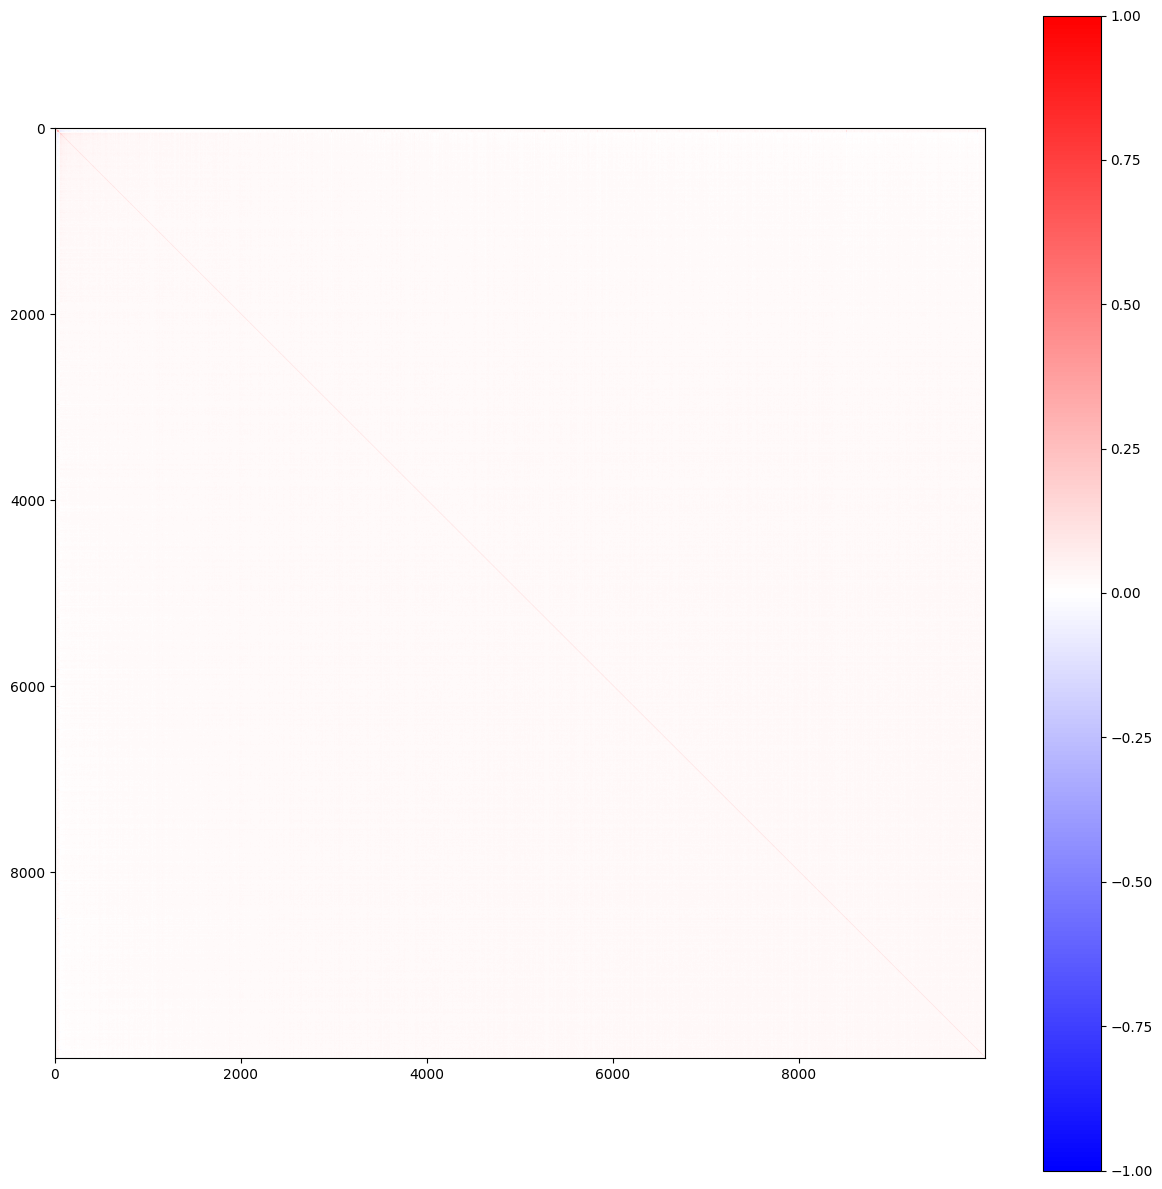

In [308]:
plt.figure(figsize=(15,15))
plt.imshow(pairwise.cpu().numpy(),vmin=-1,vmax=1,cmap='bwr')
plt.colorbar()

In [37]:
T = TreeIndex(blocks = [1000, 1000], k_per_level = [2000, 10], device=X.device)
T.fit(X.float())


In [38]:
candidate_list_sizes = []
recall_top10 = []
recall_top100= []
for example_id in range(4000):
    # example_id = 11
    x = Q[example_id].float()
    outsearch = T.search(x, 1000000, beam1=500, beam2=5)
    recalled = torch.isin(gt_idx[example_id, :100], outsearch[0])
    candidate_list_sizes.append(outsearch[0].shape[0])
    recall_top10.append(recalled[:10].sum().item()/10)
    recall_top100.append(recalled[:100].sum().item()/100)


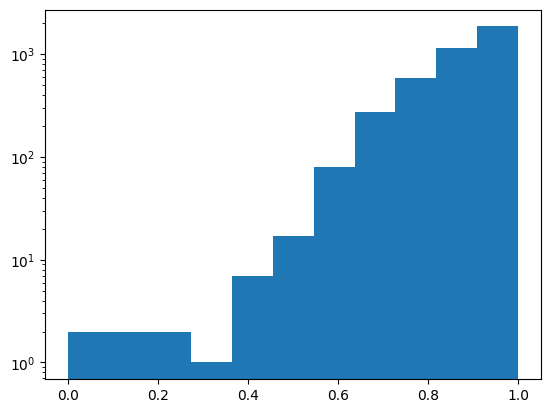

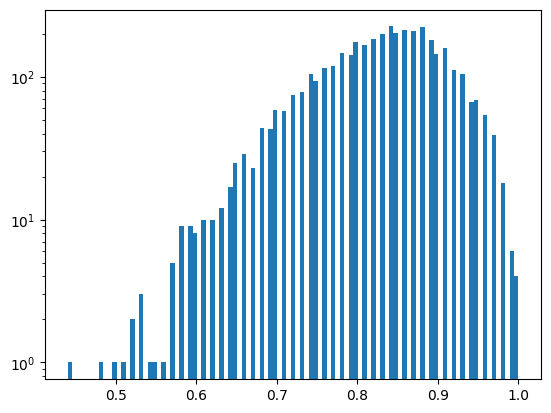

In [39]:
plt.figure()
plt.hist(recall_top10, bins=11);
plt.yscale('log')
plt.figure()
plt.hist(recall_top100, bins=101);
plt.yscale('log')

In [35]:
candidate_list_sizes = []
recall_top10 = []
recall_top100= []
for example_id in range(4000):
    # example_id = 11
    x = Q[example_id].float()
    outsearch = T.search(x, 1000000, beam1=200, beam2=10)
    recalled = torch.isin(gt_idx[example_id, :100], outsearch[0])
    candidate_list_sizes.append(outsearch[0].shape[0])
    recall_top10.append(recalled[:10].sum().item()/10)
    recall_top100.append(recalled[:100].sum().item()/100)



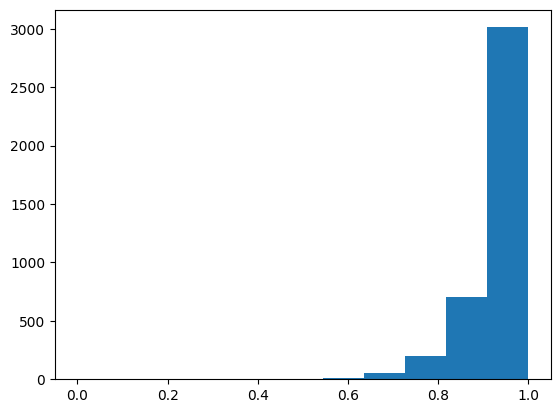

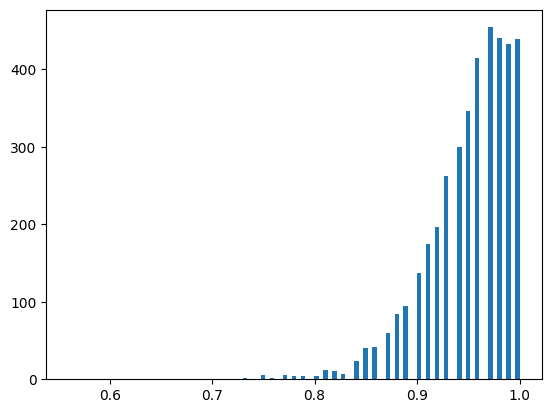

In [36]:
plt.figure()
plt.hist(recall_top10, bins=11);
# plt.yscale('log')
plt.figure()
plt.hist(recall_top100, bins=101);
# plt.yscale('log')

In [ ]:

T = TreeIndex(blocks = [256, 256], k_per_level = [2000, 10], device=X.device)
T.fit(X.float())


In [230]:

T = TreeIndex(blocks = [256, 256], k_per_level = [50, 1000], device=X.device)
T.fit(X.float())

In [12]:
T = TreeIndex(blocks = [256, 256], k_per_level = [50, 1000], device=X.device)
T.fit(X.float())

In [249]:
T2 = TreeIndex(blocks = [50, 256], k_per_level = [50, 1000], device=X.device)
T2.fit(X.float())

In [251]:
T3 = TreeIndex(blocks = [256, 1024], k_per_level = [100, 500], device=X.device)
T3.fit(X.float())

In [263]:
candidate_list_sizes = []
recall_top10 = []
recall_top100= []
for example_id in range(4000):
    # example_id = 11
    x = Q[example_id].float()
    outsearch = T.search(x, 1000000, beam1=10, beam2=500)
    recalled = torch.isin(gt_idx[example_id, :100], outsearch[0])
    candidate_list_sizes.append(outsearch[0].shape[0])
    recall_top10.append(recalled[:10].sum().item()/10)
    recall_top100.append(recalled[:100].sum().item()/100)


In [266]:
sum(candidate_list_sizes)/4000

25782.38375

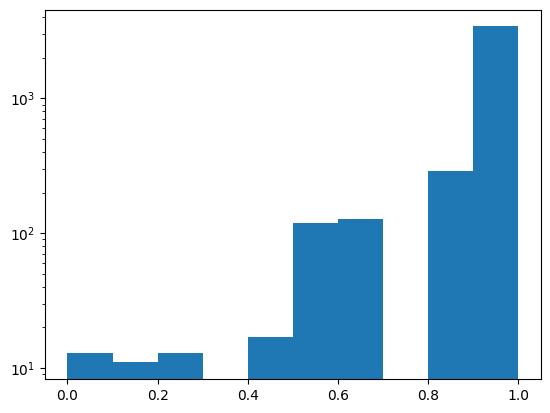

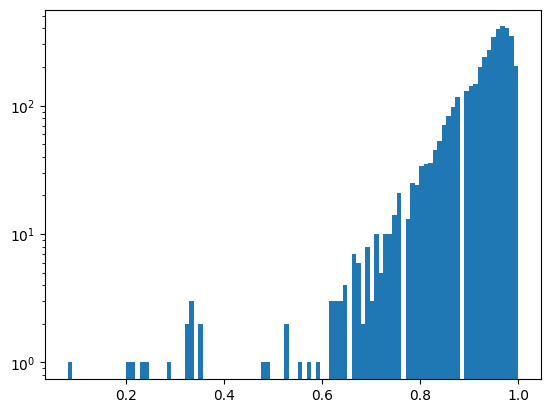

In [264]:
plt.figure()
plt.hist(recall_top10);
plt.yscale('log')
plt.figure()
plt.hist(recall_top100, bins=100);
plt.yscale('log')

In [261]:
candidate_list_sizes = []
recall_top10 = []
recall_top100= []
for example_id in range(4000):
    # example_id = 11
    x = Q[example_id].float()
    outsearch = T2.search(x, 1000000, beam1=10, beam2=500)
    recalled = torch.isin(gt_idx[example_id, :100], outsearch[0])
    candidate_list_sizes.append(outsearch[0].shape[0])
    recall_top10.append(recalled[:10].sum().item()/10)
    recall_top100.append(recalled[:100].sum().item()/100)


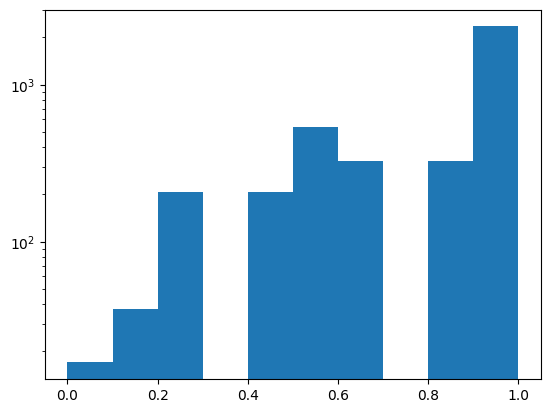

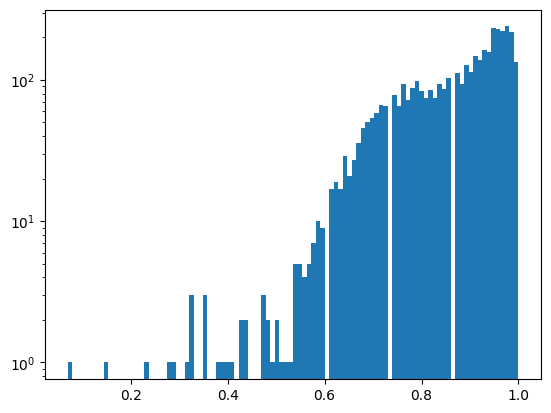

In [262]:
plt.figure()
plt.hist(recall_top10);
plt.yscale('log')
plt.figure()
plt.hist(recall_top100, bins=100);
plt.yscale('log')

In [258]:
candidate_list_sizes = []
recall_top10 = []
recall_top100= []
for example_id in range(4000):
    # example_id = 11
    x = Q[example_id].float()
    outsearch = T3.search(x, 1000000, beam1=20, beam2=250)
    recalled = torch.isin(gt_idx[example_id, :100], outsearch[0])
    candidate_list_sizes.append(outsearch[0].shape[0])
    recall_top10.append(recalled[:10].sum().item()/10)
    recall_top100.append(recalled[:100].sum().item()/100)


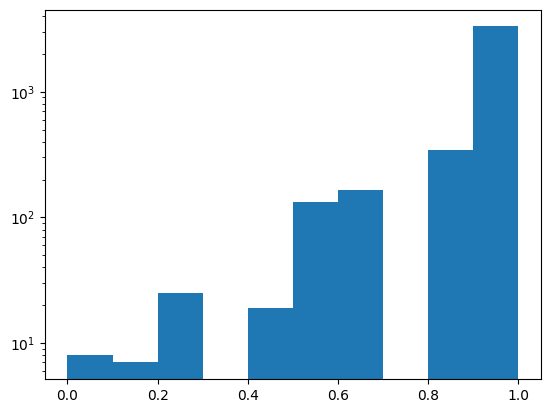

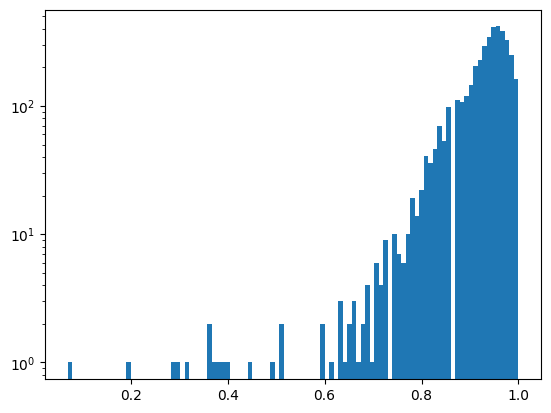

In [260]:
plt.figure()
plt.hist(recall_top10);
plt.yscale('log')
plt.figure()
plt.hist(recall_top100, bins=100);
plt.yscale('log')

In [176]:
import torch
import matplotlib.pyplot as plt
from typing import Literal, Tuple

@torch.no_grad()
def progressive_dot_error_stats_vec(
    Q: torch.Tensor,             # (Q, D)  queries in *rotated* basis
    R: torch.Tensor,             # (N, D)  rotated items (rows = items)
    deviation: Literal["std","minmax"] = "std",
    abs_error: bool = True,
    item_chunk: int = 2048,      # tune to fit memory; vectorization is inside each chunk
    device: torch.device | str | None = None,
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Vectorized per chunk:
      contrib = einsum('qd,nd->qnd')  -> (Q, nC, D)
      partial = cumsum(contrib, dim=2) -> running dot across PCs
      full    = partial[..., -1]       -> final dot per pair
      err     = |full - partial|       -> (Q, nC, D)
      reduce over (Q, nC) -> stats vs kept dims (D,)
    Returns: ks (1..D), mean_e, low, high  (each (D,))
    """
    dev = torch.device(device) if device is not None else (Q.device if Q.is_cuda else R.device)
    Q = Q.to(dev).float()
    R = R.to(dev).float()

    Qn, D = Q.shape
    N = R.shape[0]
    ks = torch.arange(1, D+1, device=dev)

    # accumulators across item chunks
    if deviation == "std":
        sum_e  = torch.zeros(D, device=dev)
        sum2_e = torch.zeros(D, device=dev)
    elif deviation == "minmax":
        min_e  = torch.full((D,), float("inf"),  device=dev)
        max_e  = torch.full((D,), float("-inf"), device=dev)
        sum_e  = torch.zeros(D, device=dev)   # we’ll also return mean
    else:
        raise ValueError("deviation must be 'std' or 'minmax'")

    total_pairs = 0

    for s in tqdm(range(0, N, item_chunk)):
        e = min(s + item_chunk, N)
        Rch = R[s:e]                      # (nC, D)
        nC  = Rch.shape[0]

        # Q×R contributions for all dims, vectorized
        # (Q, nC, D)
        contrib = torch.einsum('qd,nd->qnd', Q, Rch)

        # Running dot per prefix of PCs
        partial = torch.cumsum(contrib, dim=2)        # (Q, nC, D)
        full    = partial[:, :, -1]                   # (Q, nC)
        err     = full.unsqueeze(-1) - partial        # (Q, nC, D)
        if abs_error:
            err = err.abs()

        # Reduce over (Q, nC) for each prefix dim → (D,)
        if deviation == "std":
            sum_e  += err.sum(dim=(0,1))
            sum2_e += (err**2).sum(dim=(0,1))
        else:
            # min–max band
            ch_min = err.amin(dim=(0,1))
            ch_max = err.amax(dim=(0,1))
            min_e = torch.minimum(min_e, ch_min)
            max_e = torch.maximum(max_e, ch_max)
            sum_e += err.sum(dim=(0,1))

        total_pairs += Qn * nC

        # free big tensors ASAP
        del contrib, partial, full, err
        torch.cuda.empty_cache() if dev.type == "cuda" else None

    if deviation == "std":
        mean_e = sum_e / total_pairs
        var_e  = (sum2_e / total_pairs) - mean_e**2
        std_e  = torch.clamp(var_e, min=0).sqrt()
        low, high = mean_e - std_e, mean_e + std_e
    else:
        mean_e = sum_e / total_pairs
        low, high = min_e, max_e

    return ks, mean_e, low, high


def plot_progressive_error(
    ks: torch.Tensor, mean_e: torch.Tensor, low: torch.Tensor, high: torch.Tensor,
    deviation: Literal["std","minmax"] = "std",
    title: str = "Progressive dot-product error vs kept principal components",
):
    x   = ks.detach().cpu().numpy()
    mu  = mean_e.detach().cpu().numpy()
    lo  = low.detach().cpu().numpy()
    hi  = high.detach().cpu().numpy()

    plt.figure(figsize=(8,5))
    plt.plot(x, mu, lw=2, label="mean error")
    if deviation == "std":
        plt.fill_between(x, lo, hi, alpha=0.25, label="mean ± std")
    else:
        plt.fill_between(x, lo, hi, alpha=0.20, label="min–max range")
    plt.xlabel("Kept dimensions (prefix along principal components)")
    plt.ylabel("Distance to full dot-product")
    plt.title(title)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [178]:
xrot = Q.float() @ T.V

In [180]:
xrot = xrot.to('cuda:3')

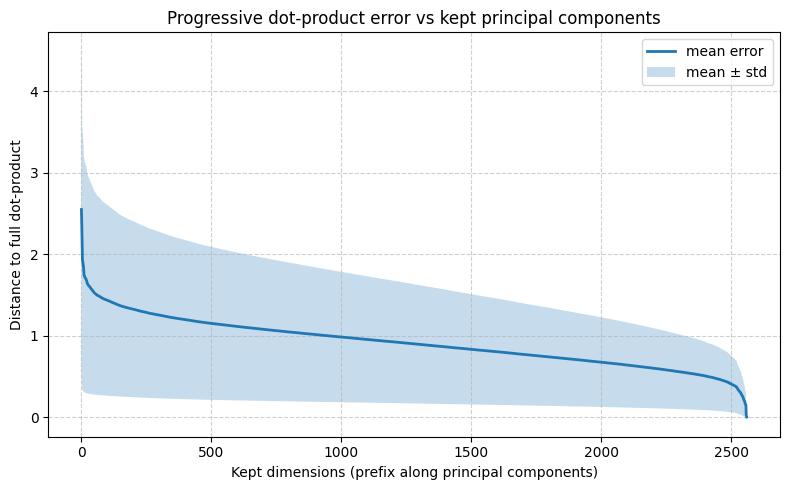

In [181]:
ks, mu, lo, hi = progressive_dot_error_stats_vec(
    xrot, T.R.to('cuda:3'), deviation="std", abs_error=True, item_chunk=100, device=xrot.device
)
plot_progressive_error(ks, mu, lo, hi, deviation="std")

In [182]:
import torch
from typing import Optional, Tuple, List

@torch.no_grad()
def _topk_over_items_in_chunks(
    Q: torch.Tensor,   # (Q, D)
    R: torch.Tensor,   # (N, D)
    k: int,
    item_chunk: int = 8192,
) -> torch.Tensor:
    """
    Return per-row top-k indices for Q @ R^T via chunked computation.
    No full (Q,N) score matrix is materialized.
    """
    dev = Q.device
    Qn = Q.shape[0]
    N  = R.shape[0]

    # Start with empty buffers
    best_vals = torch.full((Qn, 0), float("-inf"), device=dev)
    best_idx  = torch.empty(Qn, 0, dtype=torch.long, device=dev)

    for s in range(0, N, item_chunk):
        e = min(s + item_chunk, N)
        # (Q, nC)
        S = Q @ R[s:e].T
        # concat with previous best
        cand_vals = torch.cat([best_vals, S], dim=1)  # (Q, prev + nC)
        cand_idx  = torch.cat([best_idx, torch.arange(s, e, device=dev).unsqueeze(0).expand(Qn, -1)], dim=1)

        # keep top-k
        topv, topi = torch.topk(cand_vals, k=min(k, cand_vals.shape[1]), dim=1)
        best_vals = topv
        best_idx  = cand_idx.gather(1, topi)

        # free
        del S, cand_vals, cand_idx, topv, topi

    # If fewer than k items overall, pad (not typical)
    if best_idx.shape[1] < k:
        pad = k - best_idx.shape[1]
        best_idx = torch.nn.functional.pad(best_idx, (0, pad), value=-1)

    return best_idx[:, :k]  # (Q,k)


@torch.no_grad()
def _coverage_ok_for_M(
    Q: torch.Tensor, R: torch.Tensor,
    gt_topk: torch.Tensor,              # (Q, Kgt)
    M: int, candK: int = 10_000,
    item_chunk: int = 8192,
    rows_to_check: Optional[torch.Tensor] = None,  # Long indices of queries to evaluate (for per-row search)
) -> torch.Tensor:
    """
    Check coverage condition for a given prefix M:
      For each selected query, is GT@Kgt a subset of EarlyTop@candK
      computed with Q[:,:M] and R[:,:M] ?
    Returns a boolean mask of shape (Q,) where True=covered; if rows_to_check
    is provided, only those rows are computed and others are returned as True by default.
    """
    dev = Q.device
    Qn, D = Q.shape
    Kgt = gt_topk.shape[1]
    M = min(M, D)

    # rows to process
    if rows_to_check is None:
        rows_to_check = torch.arange(Qn, device=dev)
    sel = rows_to_check

    # Early top candK on the prefix
    Qp = Q[:, :M]
    Rp = R[:, :M]
    # We only need topK for selected rows; compute in one pass and slice
    early_top = _topk_over_items_in_chunks(Qp, Rp, k=candK, item_chunk=item_chunk)  # (Q, candK)
    early_top_sel = early_top.index_select(0, sel)                                   # (|sel|, candK)

    # Membership test per row using torch.isin on each row (loop over selected rows)
    covered = torch.ones(Qn, dtype=torch.bool, device=dev)
    gt_sel = gt_topk.index_select(0, sel)                                            # (|sel|, Kgt)
    for i in range(sel.numel()):
        cand = early_top_sel[i]
        gt   = gt_sel[i]
        ok = torch.isin(gt, cand).all()  # full inclusion
        covered[sel[i]] = ok

    return covered


@torch.no_grad()
def minimal_M_for_perfect_gt_coverage(
    Q_rot: torch.Tensor,               # (Q, D) queries already rotated into PCA/SVD space
    R_rot: torch.Tensor,               # (N, D) items already rotated (rows = items)
    gt_k: int = 100,                   # size of ground truth set
    candK: int = 10_000,               # early candidate set size
    item_chunk: int = 8192,
    M_start: int = 16,                 # starting M for exponential search
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    For each query, find the minimal prefix M such that
      GT_top{gt_k}(full) ⊆ EarlyTop_{candK}(prefix M)
    Returns:
      M_star: (Q,) minimal M per query (or D if never reaches coverage)
      gt_topk: (Q, gt_k) the ground truth indices (full dot)
    """
    dev = Q_rot.device
    Qn, D = Q_rot.shape

    # 1) Build full GT@gt_k once (with all D)
    gt_topk = _topk_over_items_in_chunks(Q_rot, R_rot, k=gt_k, item_chunk=item_chunk)  # (Q, gt_k)

    # 2) Exponential search to bracket per-query M
    M_low  = torch.zeros(Qn, dtype=torch.int32, device=dev)      # last failing M
    M_high = torch.full((Qn,), D, dtype=torch.int32, device=dev) # first passing M (init to D)
    unresolved = torch.ones(Qn, dtype=torch.bool, device=dev)

    M = min(M_start, D)
    while unresolved.any() and M <= D:
        covered = _coverage_ok_for_M(Q_rot, R_rot, gt_topk, M=M, candK=candK,
                                     item_chunk=item_chunk, rows_to_check=unresolved.nonzero(as_tuple=False).flatten())
        # Update brackets
        newly_ok   = unresolved & covered
        newly_fail = unresolved & (~covered)

        # For passing rows, set high bound
        M_high[newly_ok] = M
        # For failing rows, set low bound (at least M)
        M_low[newly_fail] = M

        # Mark resolved if high bound found
        unresolved = unresolved & (~newly_ok)

        # Increase M exponentially
        if M == D:
            break
        M = min(D, max(M + 1, M * 2))

    # 3) Binary search per row between (M_low, M_high)
    #    Only rows with M_low < M_high need refinement.
    todo = (M_low < M_high)
    while todo.any():
        mid = ((M_low.to(torch.int64) + M_high.to(torch.int64)) // 2).to(torch.int32)
        rows = todo.nonzero(as_tuple=False).flatten()
        M_mid = mid[rows]  # per-row mid

        # Evaluate coverage at per-row mids.
        # We can't pass different M per row into a single call, so evaluate unique mids in groups:
        unique_Ms = torch.unique(M_mid)
        for m in unique_Ms.tolist():
            rows_m = rows[(M_mid == m).nonzero(as_tuple=False).flatten()]
            cov_m = _coverage_ok_for_M(Q_rot, R_rot, gt_topk, M=m, candK=candK,
                                       item_chunk=item_chunk, rows_to_check=rows_m)
            # Update bounds for those rows
            ok_rows   = rows_m[cov_m[rows_m]]
            fail_rows = rows_m[~cov_m[rows_m]]
            M_high[ok_rows]  = torch.minimum(M_high[ok_rows], torch.tensor(m, dtype=torch.int32, device=dev))
            M_low[fail_rows] = torch.maximum(M_low[fail_rows], torch.tensor(m, dtype=torch.int32, device=dev))

        # Update todo
        todo = (M_high - M_low > 1)

    # Minimal M is the high bound (first passing M); if never passed, it's D
    M_star = M_high.clone()
    return M_star, gt_topk


In [185]:
T.R.device

device(type='cuda', index=6)

In [193]:
Q.shape

torch.Size([4000, 2560])

In [201]:
M_star, gt_topk = minimal_M_for_perfect_gt_coverage(
    xrot, T.R.to('cuda:3'),
    gt_k=50, candK=10000,
    item_chunk=1000000,   # tune for memory
    M_start=16
)

print("Per-query minimal M stats:",
      f"median={int(M_star.median())}",
      f"p90={int(torch.quantile(M_star.float(), 0.9))}",
      f"max={int(M_star.max())}")


Per-query minimal M stats: median=58 p90=276 max=2559


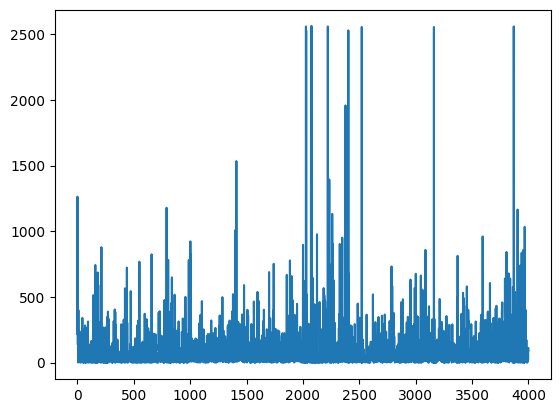

In [200]:
plt.plot(M_star.cpu().detach().numpy())

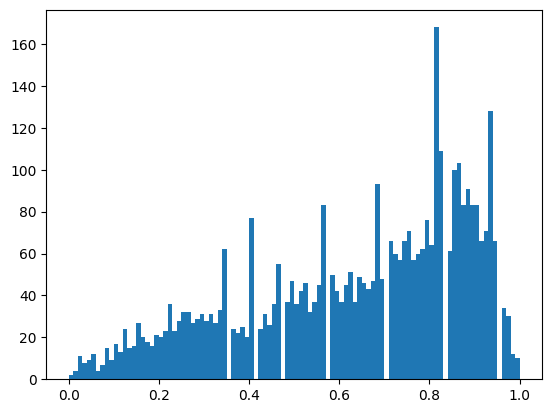

In [166]:
plt.hist(recall_top100, bins=100);

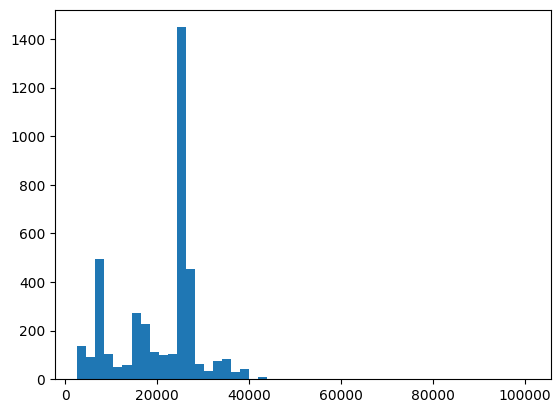

In [157]:
plt.hist(candidate_list_sizes, bins=50);

In [10]:
X.shape

torch.Size([262208, 2560])

In [165]:
r, v = pca_rotate(X.float())

dimension_cuts = [128, 512]
dimension_cuts += [D - dimension_cuts[0] - dimension_cuts[1]]
nodes_per_level= [50, 100, 200]

tree_level1_clusters, tree_level1_labels = kmeans_chunked(
    X=r[:, :dimension_cuts[0]],                        # (GPU tensor now)
    n_clusters=nodes_per_level[0],
    max_iters=50,
    tol=1e-4,
    chunk_size=N,               # process all points per pass on H100
    init_subset=init_subset,
    device=device,
    verbose=False,
)

In [173]:
v.shape

torch.Size([2560, 2560])

In [171]:
tree_level1_labels

tensor([ 7, 43, 25,  ..., 22, 22, 22])

In [54]:
Q[:, :8].mean(dim=0).shape

torch.Size([8])

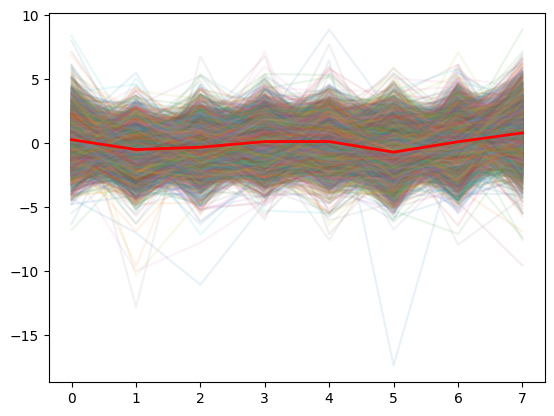

In [62]:
plt.plot(Q[:, :8].T.float().detach().cpu().numpy(), alpha=0.1);
plt.plot(Q[:, :8].mean(dim=0).detach().float().cpu().numpy(), color='red', alpha=1, linewidth=2);

## Hadamard Matrix Hashing

In [63]:
import math
import torch

def hadamard(n: int,
             *,
             device=None,
             dtype=torch.float32,
             normalized: bool = False) -> torch.Tensor:
    """
    Sylvester Hadamard matrix H_n with entries in {+1, -1}.
    n must be a power of two.
    If normalized=True, returns H / sqrt(n) (orthonormal rows).
    """
    assert n >= 1 and (n & (n - 1)) == 0, "n must be a power of two"
    H = torch.ones((1, 1), device=device, dtype=dtype)
    k = 1
    while k < n:
        H = torch.cat([
            torch.cat([H,  H], dim=1),
            torch.cat([H, -H], dim=1),
        ], dim=0)
        k <<= 1
    if normalized:
        H = H / math.sqrt(n)
    return H

def fwht(x: torch.Tensor, dim: int = -1, normalize: bool = False) -> torch.Tensor:
    """
    Fast Walsh–Hadamard Transform along a given dimension.
    - x: tensor with length power-of-two along `dim`
    - returns a *new* tensor (not in-place)
    """
    N = x.size(dim)
    assert N >= 1 and (N & (N - 1)) == 0, "transform length must be a power of two"

    # Move transform axis to the end for clean reshapes
    y = x.movedim(dim, -1).contiguous()
    shape = y.shape  # (..., N)

    h = 1
    while h < N:
        # reshape last axis: (..., N//(2h), 2, h)
        y = y.view(-1, N // (2*h), 2, h)
        a = y[:, :, 0, :].clone()
        b = y[:, :, 1, :].clone()
        y[:, :, 0, :] = a + b
        y[:, :, 1, :] = a - b
        y = y.view(*shape)
        h <<= 1

    if normalize:
        y = y / math.sqrt(N)

    return y.movedim(-1, dim)


def expand_mask(query, masks):
    if len(query.shape) == 1: # (D, )
        return query.unsqueeze(0).expand_as(masks) * masks
    return query.unsqueeze(1) * masks



In [64]:
Q.shape

torch.Size([4000, 2560])